Copy made from smarteye_video_jdsmodel.Rnw to python code for understanding and readability

Original Author: Dr. Yeasmin Khadakar<br>
Python convert: Vipul Jain

% In this report I plot Velocity vs Amplitude for each device, 
% (1) real sense, (2) real sense+ visage, (3) Smart eye, (4) smart eye+ visage (when ready)
% According to Murray, the high correlation in linear relationship between amplitude & velocity is the prime 
% determinant of the JDS algorithm. 

% The subjects recorded using real sense are different from the subjects recorded by smart eye.

% Two files needed to subset to get the amplitude and velocity for the blinks
% file name : "..blinks", In "blinks" gives information on TRUE blinks only
% record start+2 = starting row number; end+2 = end row number
 
% subset "time domain" file using starting row numbers & ending row numbers 
% Plot S_smoothed EM = Amplitude & S_Velocity = velocity

# Introduction

The linear relationship between amplitude and velocity is the backbone of the JDS algorithm. The measurement obtained from glasses usually hold this relaitonship but measurements from other devices, like **Smart Eye and Real Sense** is yet to examined. This report examined  the linear relationship using scatter plots and Perason Correlation coefficient between amplitude and velocity measured by different devices. To understand the behaviour of a video recording device, a comparison of the linear relationship between a video recording device and glasses measurement obtained within a same recording session also carried out. So far we have used two video systems, Smart Eye and Real Sense, and an image processing system, **Visage**. We have data collected over following combinations:
- Smart Eye
- Real Sense
- Real Sense + Visage processing

It is also noted that the linear relarionship between amplitude and velocity holds for only events categorised as `saccades' and blinks`. Since saccades can not be categorised from video recording, in this report only events caegorised as `blinks' are included`. however, they does not have to be blink correct shape'. 



- Relationship between Amplitude and Velocity
- Relaitonship between ZCI and BTD separated for alert and impaired sessions
- Relationship between BECD and BTD separated for alert and impaired sessions


## SmartEye

The recordings from Smart Eye has gone through many steps of processing to obtain signal as close to the corresponding glasses signal. In this report the sessions available in the folder ``T:\textbackslash 6-SW\textbackslash OptalertVideo\textbackslash JTV\_original`` <font color = 'blue'> [file location changed]</font> to `N:\Vault\VIDEO_VAULT\2.Aquila\JTV_original\`, are used and decisions to which sessions to be used is available i nthe Decisions.tx file in the same folder.


### Relationship betwen Amplitude and Velocity: Individual session

*15 min is last 15 mins of the test*

In [1]:
import pandas as pd

# read the Decisions.txt file (no header)
sm_decisions = pd.read_csv(
    r"N:\Vault\VIDEO_VAULT\2.Aquila\JTV_original\Decisions.txt",
    header=None
)

# ensure first column is string
sm_decisions[0] = sm_decisions[0].astype(str)

# split on '=='
# split_cols = sm_decisions[0].str.split("==", expand=True)
split_cols = sm_decisions[0].str.split("==", expand=True)


# trim whitespace
sm_decisions["session"] = split_cols[0].str.strip()
sm_decisions["decision"] = split_cols[1].str.strip()

# rename columns
sm_decisions = sm_decisions.rename(columns={0: "name"})[
    ["name", "session", "decision"]
]

# use sessions with "IN" decisions
sm_in = sm_decisions.loc[sm_decisions["decision"] == "IN", "session"]

# remove NA entries
sm_in = sm_in.dropna()


In [2]:
import os
import pandas as pd
sm_root_dir = r"N:\Vault\VIDEO_VAULT\2.Aquila\JTV_original"
# Get folder name for all sessions available in sm_root_dir
sm_session_all = sm_root_dir + "/" + sm_decisions["session"]

# manual fix: delete 3 sessions (no information available) per original but Decisions.txt found now doesn't have the below session
exclude_sessions = {
    "20160809_1800_tm",
    "20160810_0300_tm",
    "20160810_0400_tm"
}

sm_session_all = sm_session_all[
    ~sm_session_all.apply(lambda x: os.path.basename(x) in exclude_sessions)
]

# Get folder name for IN sessions
sm_session_in = sm_root_dir + "/" + sm_in

# device names
sm_device = ["glasses", "smarteye"]


In [3]:
sm_session_in

2     N:\Vault\VIDEO_VAULT\2.Aquila\JTV_original/201...
4     N:\Vault\VIDEO_VAULT\2.Aquila\JTV_original/201...
6     N:\Vault\VIDEO_VAULT\2.Aquila\JTV_original/201...
10    N:\Vault\VIDEO_VAULT\2.Aquila\JTV_original/201...
13    N:\Vault\VIDEO_VAULT\2.Aquila\JTV_original/201...
15    N:\Vault\VIDEO_VAULT\2.Aquila\JTV_original/201...
17    N:\Vault\VIDEO_VAULT\2.Aquila\JTV_original/201...
18    N:\Vault\VIDEO_VAULT\2.Aquila\JTV_original/201...
19    N:\Vault\VIDEO_VAULT\2.Aquila\JTV_original/201...
20    N:\Vault\VIDEO_VAULT\2.Aquila\JTV_original/201...
21    N:\Vault\VIDEO_VAULT\2.Aquila\JTV_original/201...
22    N:\Vault\VIDEO_VAULT\2.Aquila\JTV_original/201...
23    N:\Vault\VIDEO_VAULT\2.Aquila\JTV_original/201...
24    N:\Vault\VIDEO_VAULT\2.Aquila\JTV_original/201...
25    N:\Vault\VIDEO_VAULT\2.Aquila\JTV_original/201...
26    N:\Vault\VIDEO_VAULT\2.Aquila\JTV_original/201...
27    N:\Vault\VIDEO_VAULT\2.Aquila\JTV_original/201...
28    N:\Vault\VIDEO_VAULT\2.Aquila\JTV_original

In [4]:
# Store percentage calculated from JTV
sm_jtv = []

# store per-minute n_lapsing and n_stimuli
sm_pm_lapsing = []

# Store blink data from glasses and video
sm_dt = []

# Store slope, corr, n from glasses and video condition on type
sm_stat = []

# sessions to work with:
# choose IN sessions or all sessions
sm_work_session = list(sm_session_in)


In [5]:
import os
import glob
import math
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns  # for easier lm line


# helper function for groupby
def compute_stats(group):
    if len(group) < 2:
        return pd.Series({
            'n_events': len(group),
            'slope': np.nan,
            'correlation': np.nan
        })
    
    # Linear regression: maxamp ~ maxvel
    reg = LinearRegression().fit(group[['maxvel']], group['maxamp'])
    slope = reg.coef_[0]
    
    # Pearson correlation
    correlation = group['maxamp'].corr(group['maxvel'], method='pearson')
    
    return pd.Series({
        'n_events': len(group),
        'slope': slope,
        'correlation': correlation
    })

#################### Start looping ##########################
for s in range(len(sm_work_session)):
    #########################  JTV stuff ##################
    session_path = sm_work_session.iloc[s] if hasattr(sm_work_session, "iloc") else sm_work_session[s]

    # find *_jtv_* folder
    jtv_path = glob.glob(os.path.join(session_path, "*_jtv_*"))

    if not jtv_path:
        continue  # safety: skip if no JTV folder found

    # read ReactionTimes.csv
    react_file = glob.glob(os.path.join(jtv_path[0], "*ReactionTimes.csv"))

    if not react_file:
        continue

    react = pd.read_csv(
        react_file[0],
        header=0
    )

    # allocate the state depending on the entry
    react["state"] = 0  # "not_lapsing"
    react.loc[react.iloc[:, 2] == "---", "state"] = 1  # "lapsing"

    # Calculate the minute start_time and end_time from the Time column
    nr = len(react)
    lastmin = math.ceil(react.iloc[nr - 1, 1] / 60)

    start_time = np.arange(0, lastmin * 60 + 1, 60)
    end_time = start_time + 59.998
    window = np.arange(len(start_time))

    ####################  per minute reaction output  ######################
    session_name = os.path.basename(session_path)

    decision = sm_decisions.loc[
        sm_decisions["session"] == session_name, "decision"
    ].str.upper().values

    react_pm = pd.DataFrame({
        "session": [session_name] * len(start_time),
        "decision": [decision] * len(start_time),
        "start_time": start_time,
        "end_time": end_time,
        "window": window,
        "n_stimuli": [0] * len(start_time),
        "n_lapses": [0] * len(start_time),
    })

    # Calculate per-minute counts FIRST (this part was correct)
    for i in range(1, len(react_pm)):
        tmp = react[(react.iloc[:, 1] > react_pm.loc[i-1, 'start_time']) & 
                    (react.iloc[:, 1] <= react_pm.loc[i, 'start_time'])]
        react_pm.loc[i, 'n_stimuli'] = len(tmp)
        react_pm.loc[i, 'n_lapses'] = tmp['state'].sum()

    # First minute
    tmp = react[react.iloc[:, 1] <= react_pm.loc[0, 'start_time']]
    react_pm.loc[0, 'n_stimuli'] = len(tmp)
    react_pm.loc[0, 'n_lapses'] = tmp['state'].sum()

    # NOW calculate JTV percentages (FIXED)
    total_lapses_20min = react_pm['n_lapses'].sum()
    total_stimuli_20min = react_pm['n_stimuli'].sum()
    total_lapses_15min = react_pm.loc[react_pm['window'] >= 6, 'n_lapses'].sum()
    total_stimuli_15min = react_pm.loc[react_pm['window'] >= 6, 'n_stimuli'].sum()

    jtv_percentage = pd.DataFrame({
        'session': [react_pm['session'].iloc[0]],
        'decision': [react_pm['decision'].iloc[0]],
        'JTV_percentage_20min': [round(100 * total_lapses_20min / total_stimuli_20min, 2)],
        'JTV_percentage_last15min': [round(100 * total_lapses_15min / total_stimuli_15min, 2)]
    })

    # Append to lists
    sm_jtv.append(jtv_percentage)
    sm_pm_lapsing.append(react_pm)


    # ########################## Glasses blinks ########################
    # Read glasses blink file
    blink_file_path = os.path.join(sm_work_session[s], sm_device[0], "*blink_correct_shape.csv")
    blink_files = glob.glob(blink_file_path, recursive=True)
    if blink_files:
        smb_gl = pd.read_csv(blink_files[0])
        smb_gl.columns = [_.strip() for _ in smb_gl.columns]
    else:
        continue  # Skip if no blink file found

    smb_gl['device'] = "Glasses"
    smb_gl['session'] = os.path.basename(sm_work_session[s])

    # Calculate window for each blink using start_time and end_time
    smb_gl['window'] = 0

    for t in range(len(start_time)):
        # Find blinks where t_start > start_time[t] AND t_end <= end_time[t]
        mask = (smb_gl['t_start'] > start_time[t]) & (smb_gl['t_end'] <= end_time[t])
        smb_gl.loc[mask, 'window'] = t  # Python 0-indexed, so t instead of t-1

    
    # ########################## SmartEye blinks ########################
    # Read glasses blink file
    blink_file_path = os.path.join(sm_work_session[s], sm_device[1], "*blink_correct_shape.csv")
    blink_files = glob.glob(blink_file_path, recursive=True)
    if blink_files:
        smb_sm = pd.read_csv(blink_files[0])
        smb_sm.columns = [_.strip() for _ in smb_sm.columns]
    else:
        continue  # Skip if no blink file found

    smb_sm['device'] = "SmartEye"
    smb_sm['session'] = os.path.basename(sm_work_session[s])

    # Calculate window for each blink using start_time and end_time
    smb_sm['window'] = 0

    for t in range(len(start_time)):
        # Find blinks where t_start > start_time[t] AND t_end <= end_time[t]
        mask = (smb_sm['t_start'] > start_time[t]) & (smb_sm['t_end'] <= end_time[t])
        smb_sm.loc[mask, 'window'] = t  # Python 0-indexed, so t instead of t-1

    # combine two device's data (equivalent to sm_dt[[s]] <- rbind(smb_gl, smb_sm))
    sm_dt_s = pd.concat([smb_gl, smb_sm], ignore_index=True)

    # ensure 'type' is a categorical column with levels c("1", "-1")
    sm_dt_s['type'] = pd.Categorical(sm_dt_s['type'], categories=[1, -1], ordered=False)

    # if you're keeping a per-session list like in R:
    sm_dt.append(sm_dt_s)


    # ---------------- stats block per session ----------------
    df_session = sm_dt_s  # same as sm_dt[[s]] in R
    # 1) n_events, slope, correlation
    g = df_session.groupby(['session', 'device', 'type'], dropna=False)
    statf = g.apply(compute_stats).reset_index()

    # round and order by type
    statf['n_events'] = statf['n_events'].round(2)
    statf['slope'] = statf['slope'].round(2)
    statf['correlation'] = statf['correlation'].round(2)
    statf = statf.sort_values('type')

    # 2) mean and sd of avr (unchanged)
    stat_avr = (
        g['avr']
        .agg(mean_avr=lambda x: round(x.mean(), 3),
            sd_avr=lambda x: round(x.std(ddof=1), 3))
        .reset_index()
        .sort_values('type')
    )

    # 3) merge (right_join equivalent)
    statf = statf.merge(stat_avr, on=['session', 'device', 'type'], how='right')

    # 4) store per session
    sm_stat.append(statf)

    # # ######################## organise plots - COMPLETE REPLACEMENT ####################
    # fig, (ax_scatter, ax_stats, ax_jtv) = plt.subplots(
    #     3, 1, figsize=(12, 12), 
    #     gridspec_kw={'height_ratios': [7, 2, 1], 'hspace': 0.3}
    # )

    # # 1. SCATTER PLOT (top, 70% height)
    # sns.set_theme(style='whitegrid')
    # g = sns.lmplot(data=sm_dt_s, x='maxvel', y='maxamp', 
    #             col='device', row='type', height=3, aspect=1.5,
    #             scatter_kws={'color': 'blue', 's': 40, 'edgecolors': 'black', 'linewidth': 0.5},
    #             line_kws={'color': 'red'})
    # g.fig.suptitle(os.path.basename(sm_work_session[s]), fontsize=14, fontweight='bold', y=0.95)
    # # Note: lmplot creates its own figure, so for simplicity we'll recreate on ax_scatter
    # ax_scatter.axis('off')  # Placeholder - lmplot needs separate handling

    # # SIMPLIFIED SCATTER (direct on subplot)
    # for idx, (device, typ) in enumerate(sm_dt_s.groupby(['device', 'type']).groups.keys()):
    #     subset = sm_dt_s[(sm_dt_s['device'] == device) & (sm_dt_s['type'] == typ)]
    #     if idx == 0:
    #         ax_scatter.scatter(subset['maxvel'], subset['maxamp'], 
    #                         color='blue', s=40, edgecolors='black', label='Data')
    #         # Add regression line
    #         z = np.polyfit(subset['maxvel'], subset['maxamp'], 1)
    #         p = np.poly1d(z)
    #         ax_scatter.plot(subset['maxvel'], p(subset['maxvel']), "red", linewidth=2)
    #     else:
    #         ax_scatter.scatter(subset['maxvel'], subset['maxamp'], 
    #                         color='blue', s=40, edgecolors='black', alpha=0.7)
    # ax_scatter.set_title(f'{os.path.basename(sm_work_session[s])}', fontsize=14, fontweight='bold', pad=20)

    # # 2. STATS TABLE (middle, 20% height)
    # ax_stats.axis('off')
    # stat_table = ax_stats.table(cellText=statf.values.tolist(),
    #                         colLabels=statf.columns.tolist(),
    #                         cellLoc='center', loc='center')
    # stat_table.auto_set_font_size(False)
    # stat_table.set_fontsize(9)
    # stat_table.scale(1, 1.8)
    # for i in range(len(statf.columns)):
    #     stat_table[(0, i)].set_facecolor('#40466e')
    #     stat_table[(0, i)].set_text_props(weight='bold', color='white')

    # # 3. JTV TABLE (bottom, 10% height)  
    # ax_jtv.axis('off')
    # jtv_table = ax_jtv.table(cellText=jtv_percentage.values.tolist(),
    #                         colLabels=jtv_percentage.columns.tolist(),
    #                         cellLoc='center', loc='center')
    # jtv_table.auto_set_font_size(False)
    # jtv_table.set_fontsize(9)
    # jtv_table.scale(1, 1.5)
    # for i in range(len(jtv_percentage.columns)):
    #     jtv_table[(0, i)].set_facecolor('#40466e')
    #     jtv_table[(0, i)].set_text_props(weight='bold', color='white')

    # plt.tight_layout()
    # plt.show()

C:\Users\VJain\AppData\Local\Temp\ipykernel_10608\1139051021.py:170: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df_session.groupby(['session', 'device', 'type'], dropna=False)
C:\Users\VJain\AppData\Local\Temp\ipykernel_10608\1139051021.py:171: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  statf = g.apply(compute_stats).reset_index()
C:\Users\VJain\AppData\Local\Temp\ipykernel_10608\1139051021.py:170: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version

In [6]:
sm_dt[0].columns

Index(['start', 'end', 't_start', 't_end', 'init_pos', 'final_pos', 'maxamp',
       'maxvel', 'tmaxvel', 'tmaxamp', 'ied', 'zci', 'doq', 'avr', 'type',
       't_minute', 't_minute_tweak', 't_minute_tweak2', 'ra_rp_event',
       'rel_amp', 'rel_pos', 'saccade', 'blink', 'becd', 'btd', 'avr_product',
       'avr_ratio', 'blink_correct_shape', 'blink_short', 'blink_long',
       'blink_closure1', 'blink_closure2', 'device', 'session', 'window'],
      dtype='object')

### Relationship betwen Amplitude and Velocity: combined sessions

In [7]:
########################### combine for all subjects ####################

# jtv whole percentage (do.call(rbind, sm_jtv))
sm_jtv_all = pd.concat(sm_jtv, ignore_index=True)

# jtv per minute lapsing (do.call(rbind, sm_pm_lapsing))
sm_jtv_pm_lapsing_all = pd.concat(sm_pm_lapsing, ignore_index=True)

# glasses & visage_smarteye data (do.call(rbind, sm_dt))
sm_dt_all = pd.concat(sm_dt, ignore_index=True)

# stat from both devices (do.call(rbind, sm_stat))
sm_stat_all = pd.concat(sm_stat, ignore_index=True)

# add JTV_percentage_20min to the data (right_join equivalent)
sm_dt_all = sm_dt_all.merge(
    sm_jtv_all[['session', 'JTV_percentage_20min']], 
    on='session', 
    how='right'
)

# add state: JTV_percentage_20min > 5% ==> impaired
sm_dt_all['state'] = 'not_impaired'
sm_dt_all.loc[sm_dt_all['JTV_percentage_20min'] > 5, 'state'] = 'impaired'

# add per minute n_lapses & n_stimuli with sm_dt_all
# remove if any NA occur due to coercion (na.omit + right_join equivalent)
blink_cols = ['session', 'window', 'n_stimuli', 'n_lapses']
jtv_pm_cols = sm_jtv_pm_lapsing_all[blink_cols].copy()

sm_dt_all = sm_dt_all.merge(
    jtv_pm_cols,
    on=['session', 'window'],
    how='right'
).dropna()


In [8]:
########################### final sessions to build model #############################
# Drop sessions according to Murray's suggestions
sm_session_drop = ["20160811_1130_pn", "20160812_0340_pn", "20160812_0440_pn", "20160817_041043_ms"]

# Filter sm_session_final (equivalent to sm_session_in[! basename(sm_session_in) %in% sm_session_drop])
sm_session_final = [path for path in sm_session_in if os.path.basename(path) not in sm_session_drop]

####################### final data #############################
# Keep only sessions in sm_session_final
sm_dt_final = sm_dt_all[sm_dt_all['session'].isin([os.path.basename(path) for path in sm_session_final])].copy()

# Convert state to categorical (factor equivalent) with specific levels
sm_dt_final['state'] = pd.Categorical(
    sm_dt_final['state'], 
    categories=['not_impaired', 'impaired'], 
    ordered=False
)


In [9]:
########### number of final session ##########
n_session_final = len(sm_session_final)
print(n_session_final)
model_device = "SmartEye"

# Print dropped sessions (equivalent to print(sm_session_drop))
print("Dropped sessions according to Murray's suggestions:")
print(sm_session_drop)


14
Dropped sessions according to Murray's suggestions:
['20160811_1130_pn', '20160812_0340_pn', '20160812_0440_pn', '20160817_041043_ms']


In [10]:
# Summary statistics for final dataset
n_not_impaired_sessions = len(sm_dt_final[sm_dt_final['state'] == 'not_impaired']['session'].unique())
n_impaired_sessions = len(sm_dt_final[sm_dt_final['state'] == 'impaired']['session'].unique())

print(f"Now we have {len(sm_session_final)} sessions, among which "
      f"{n_not_impaired_sessions} were 'not_impaired' and "
      f"{n_impaired_sessions} were 'impaired'.")


Now we have 14 sessions, among which 4 were 'not_impaired' and 10 were 'impaired'.


In [11]:
sm_dt_final[sm_dt_final['state'] == 'not_impaired']['session'].unique()

array(['20160804_111831_hz', '20160817_025620_ms', '20160819_0326_hz',
       '20160824_0330_hz'], dtype=object)


The relationship between amplitude and velocity is examined for all sessions combined and following comparison was carried: 

- comparison of relationship between maxamp and maxvel between two state of impairment. Within each state there are  the two devices and two types of events, eye closing and eye reopenning. Histograms of AVR are also produced in these four cases. A summary stat table shows the slope, correlation coefficients, mean of AVR, standard deviation of AVR in all four combinations.  
- comparison of relationship between log(Positive ZCI)  and log(BTD)
- comparison of relationship between log(Negative ZCI)  and log(BTD)
- comparison of relationship between log(BECD)  and log(BTD)

These comparisons are taken place to examine the extent of relationship between variables in the `not\_impaired and impaired subsets`. The true state of impairment is obtained using the reaction time from JTV test output that was taken place simultenously during recordinds. Usually a cut-off percentage of lapsing ($5\%$) calcualted csidering whole recording session is used to label a subject's  state of impairment. If the total JTv percentage is below $5\%$ all observations in that sessions were labelled as `not\_impaired'.

However, it is also worth to mention that human brain can show some alertness during a drowsy period, and some signs of drowsyness during an alert period. Hence, no lapsing minute can be observed even though the JTV percentage from whole recording session was above the $5\%$ arbtrary thresh-holds. To make the algorithm accostom with these brain activity, the relationship between above mentioned variables are also examined in the conditional subset of data using per minute lapsing.    



C:\Users\VJain\AppData\Local\Temp\ipykernel_10608\3349024026.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combinations = sm_gl_dt.groupby(['state', 'type']).groups.keys()


<Figure size 1400x1000 with 0 Axes>

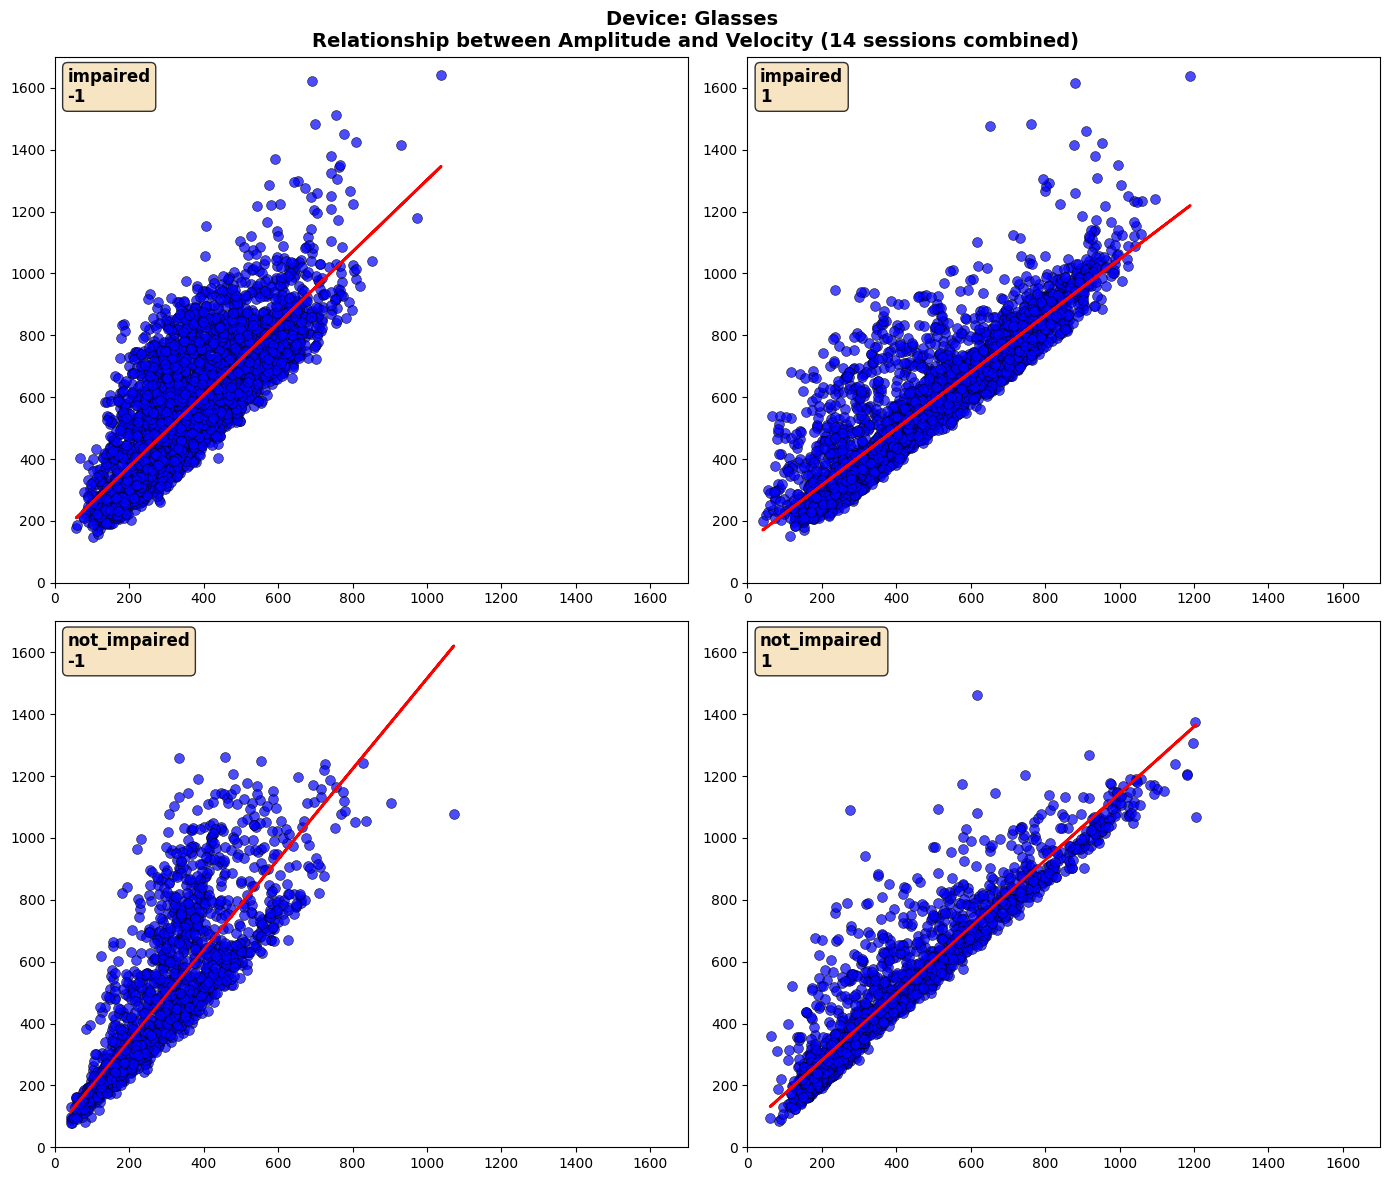

In [12]:
################# common x & y limit for not_impaired and drowsy data ##################
cx = sm_dt_final['maxvel'].min(), sm_dt_final['maxvel'].max()
cy = sm_dt_final['maxamp'].min(), sm_dt_final['maxamp'].max()

######################## not_impaired data plot ##################
# Filter for Glasses device only
sm_gl_dt = sm_dt_final[sm_dt_final['device'] == "Glasses"].copy()

# Convert type to categorical (factor equivalent)
sm_gl_dt['type'] = pd.Categorical(sm_gl_dt['type'], categories=[1, -1], ordered=False)

# Glasses scatter plot (all sessions combined)
plt.figure(figsize=(14, 10))

# Create subplot grid for 2x2 faceting (state + type)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

# Get unique combinations for faceting
combinations = sm_gl_dt.groupby(['state', 'type']).groups.keys()

for idx, (state_val, type_val) in enumerate(combinations):
    ax = axes[idx]
    
    # Filter data for this facet
    subset = sm_gl_dt[(sm_gl_dt['state'] == state_val) & (sm_gl_dt['type'] == type_val)]
    
    # Scatter points (blue, shape=21 equivalent)
    ax.scatter(subset['maxvel'], subset['maxamp'], 
               color='blue', s=50, edgecolors='black', linewidth=0.5, alpha=0.7)
    
    # Linear regression line (red)
    if len(subset) > 1:
        z = np.polyfit(subset['maxvel'], subset['maxamp'], 1)
        p = np.poly1d(z)
        ax.plot(subset['maxvel'], p(subset['maxvel']), "red", linewidth=2)
    
    # Fixed axis limits
    ax.set_xlim(0, 1700)
    ax.set_ylim(0, 1700)
    
    # Facet labels (label_both equivalent)
    ax.text(0.02, 0.98, f"{state_val}\n{type_val}", 
            transform=ax.transAxes, fontsize=12, fontweight='bold',
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle(f"Device: Glasses \n"
             f"Relationship between Amplitude and Velocity ({n_session_final} sessions combined)", 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


In [13]:
##################### slope, correlation ##################
from sklearn.linear_model import LinearRegression

def compute_regression_stats(group):
    """Calculate n_events, slope, and correlation for a group"""
    if len(group) < 2:
        return pd.Series({
            'n_events': len(group),
            'slope': np.nan,
            'correlation': np.nan
        })
    
    # Linear regression: maxamp ~ maxvel
    reg = LinearRegression().fit(group[['maxvel']], group['maxamp'])
    slope = reg.coef_[0]
    
    # Pearson correlation
    correlation = group['maxamp'].corr(group['maxvel'], method='pearson')
    
    return pd.Series({
        'n_events': len(group),
        'slope': round(slope, 3),
        'correlation': round(correlation, 3)
    })

# Calculate stats by state x type for Glasses
sm_gl_stat1 = (sm_gl_dt.groupby(['state', 'type'], dropna=False)
               .apply(compute_regression_stats)
               .reset_index()
               .sort_values('type'))

print("Glasses device statistics by state and type:")
print(sm_gl_stat1)


Glasses device statistics by state and type:
          state type  n_events  slope  correlation
0  not_impaired    1    2108.0  1.079        0.941
2      impaired    1    4144.0  0.913        0.890
1  not_impaired   -1    2108.0  1.462        0.835
3      impaired   -1    4144.0  1.159        0.791


C:\Users\VJain\AppData\Local\Temp\ipykernel_10608\3251646351.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sm_gl_stat1 = (sm_gl_dt.groupby(['state', 'type'], dropna=False)
C:\Users\VJain\AppData\Local\Temp\ipykernel_10608\3251646351.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_regression_stats)


In [14]:
#### mean & sd of avr #######################
sm_gl_stat2 = (sm_gl_dt.groupby(['state', 'type'])
               .agg(mean_avr=('avr', lambda x: round(x.mean(), 3)),
                    sd_avr=('avr', lambda x: round(x.std(ddof=1), 3)))
               .reset_index()
               .sort_values('type'))

### combine stat file #####################
sm_gl_stat3 = sm_gl_stat1.merge(sm_gl_stat2, on=['state', 'type'], how='right')
sm_gl_stat3['device'] = 'Glasses'

print("Combined Glasses statistics:")
print(sm_gl_stat3)


C:\Users\VJain\AppData\Local\Temp\ipykernel_10608\2980628271.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sm_gl_stat2 = (sm_gl_dt.groupby(['state', 'type'])


Combined Glasses statistics:
          state type  n_events  slope  correlation  mean_avr  sd_avr   device
0  not_impaired    1    2108.0  1.079        0.941     1.288   0.330  Glasses
1      impaired    1    4144.0  0.913        0.890     1.272   0.477  Glasses
2  not_impaired   -1    2108.0  1.462        0.835     1.693   0.492  Glasses
3      impaired   -1    4144.0  1.159        0.791     1.631   0.492  Glasses


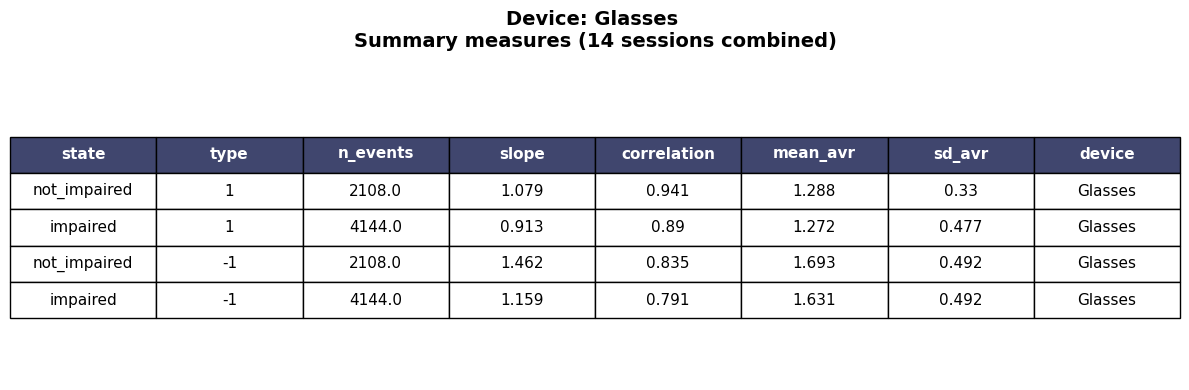

In [15]:
################ alert stat plot #########################
fig, ax = plt.subplots(figsize=(12, 4))

# Hide all axes (geom_blank() + theme axis removals equivalent)
ax.axis('tight')
ax.axis('off')

# Create table from sm_gl_stat3
col_labels = sm_gl_stat3.columns.tolist()
cell_text = sm_gl_stat3.values.tolist()

# Table (tableGrob + annotation_custom equivalent)
table = ax.table(cellText=cell_text,
                 colLabels=col_labels,
                 cellLoc='center',
                 loc='center')

# Style (ttheme_default(base_size=11))
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.2)

# Header styling (dark blue)
for i in range(len(col_labels)):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Clean background (theme_bw() equivalent)
ax.set_facecolor('white')

# Title
plt.title(f"Device: Glasses \n"
          f"Summary measures ({n_session_final} sessions combined)", 
          fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()


C:\Users\VJain\AppData\Local\Temp\ipykernel_10608\559726177.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combinations = sm_gl_dt.groupby(['state', 'type']).groups.keys()


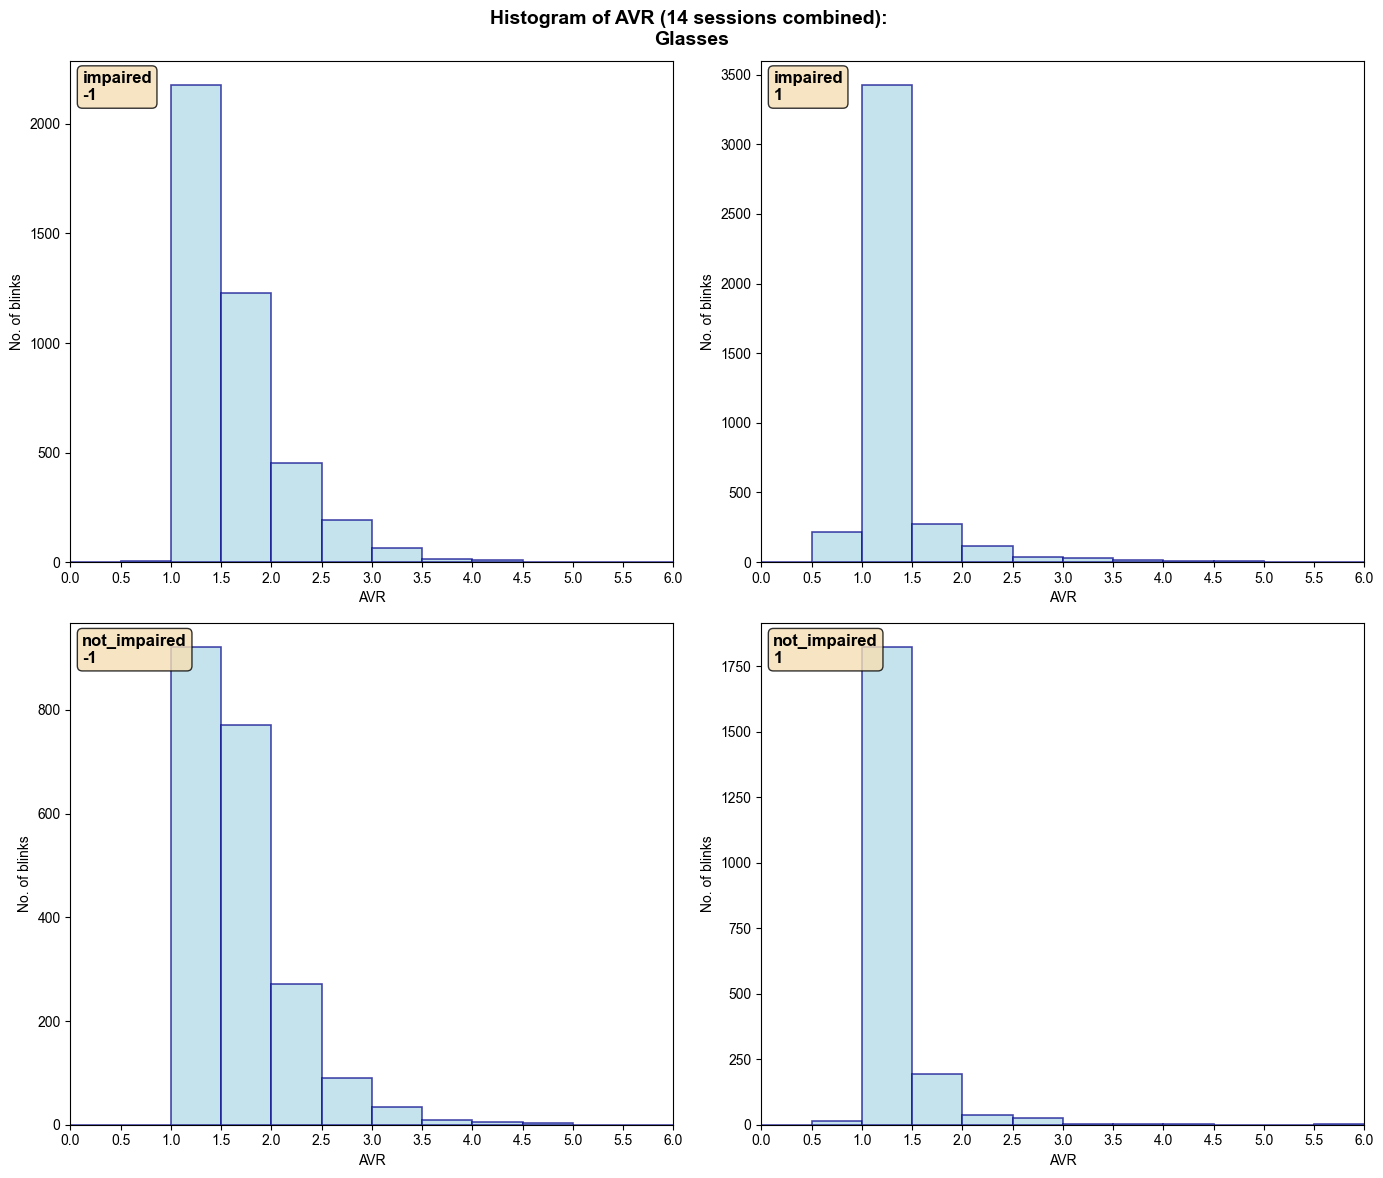

In [16]:
############### alert: histogram of AVR ##################
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

# Get unique state x type combinations
combinations = sm_gl_dt.groupby(['state', 'type']).groups.keys()

for idx, (state_val, type_val) in enumerate(combinations):
    ax = axes[idx]
    
    # Filter data for this facet
    subset = sm_gl_dt[(sm_gl_dt['state'] == state_val) & (sm_gl_dt['type'] == type_val)]
    
    # Histogram (darkblue edges, lightblue fill, binwidth=0.5)
    ax.hist(subset['avr'], bins=np.arange(0, 6.5, 0.5), 
            color='lightblue', edgecolor='darkblue', linewidth=1.2, alpha=0.7)
    
    # Fixed x-axis limits and breaks
    ax.set_xlim(0, 6)
    ax.set_xticks(np.arange(0, 6.5, 0.5))
    
    # Labels
    ax.set_xlabel('AVR')
    ax.set_ylabel('No. of blinks')
    
    # Facet labels
    ax.text(0.02, 0.98, f"{state_val}\n{type_val}", 
            transform=ax.transAxes, fontsize=12, fontweight='bold',
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Main title
plt.suptitle(f"Histogram of AVR ({n_session_final} sessions combined): \nGlasses", 
             fontsize=14, fontweight='bold', y=0.98)

# Theme_bw() equivalent + no legend
sns.set_theme(style='whitegrid')
plt.tight_layout()
plt.show()


C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


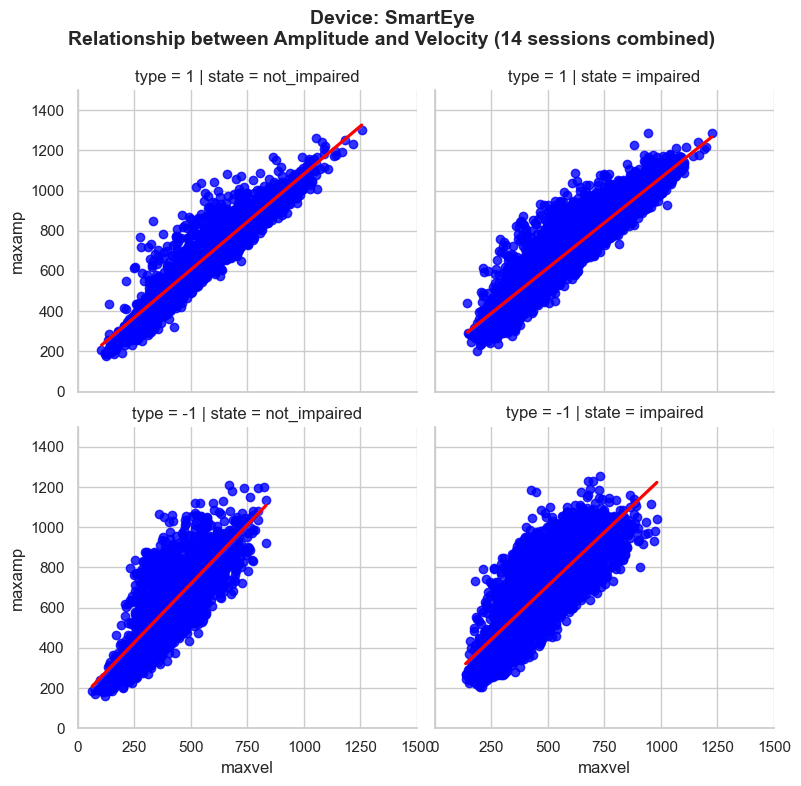

In [17]:
# -------------------- drowsy data --------------------

# Filter data for SmartEye device
sm_sm_dt = sm_dt_final[sm_dt_final["device"] == "SmartEye"].copy()

# Set 'type' as categorical with specific order
sm_sm_dt["type"] = pd.Categorical(
    sm_sm_dt["type"],
    categories=[1, -1],
    ordered=True
)

# Create faceted scatter plot with linear regression
g = sns.lmplot(
    data=sm_sm_dt,
    x="maxvel",
    y="maxamp",
    col="state",
    row="type",
    scatter_kws={"color": "blue"},
    line_kws={"color": "red"},
    height=4,
    aspect=1
)

# Set axis limits
g.set(xlim=(0, 1500), ylim=(0, 1500))

# Set overall title
g.fig.suptitle(
    f"Device: SmartEye\nRelationship between Amplitude and Velocity "
    f"({n_session_final} sessions combined)",
    fontsize=14,
    fontweight="bold",
    ha="center"
)

# Adjust layout to make room for title
g.fig.subplots_adjust(top=0.88)

# Use a clean theme similar to theme_bw()
sns.set_style("whitegrid")

plt.show()


In [18]:
import statsmodels.api as sm
from scipy.stats import pearsonr

# ---------------- slope, correlation ----------------

stat_rows = []

for (state, typ), df in sm_sm_dt.groupby(["state", "type"]):
    # Linear model: maxamp ~ maxvel
    X = sm.add_constant(df["maxvel"])
    y = df["maxamp"]
    model = sm.OLS(y, X).fit()

    slope = round(model.params["maxvel"], 3)

    # Pearson correlation
    corr, _ = pearsonr(df["maxamp"], df["maxvel"])
    corr = round(corr, 3)

    # Number of events
    n_events = round(len(df), 3)

    stat_rows.append({
        "state": state,
        "type": typ,
        "n_events": n_events,
        "slope": slope,
        "correlation": corr
    })

sm_sm_stat1 = (
    pd.DataFrame(stat_rows)
    .sort_values("type")
    .reset_index(drop=True)
)

# ---------------- mean & sd of avr ----------------

sm_sm_stat2 = (
    sm_sm_dt
    .groupby(["state", "type"], as_index=False)
    .agg(
        mean_avr=("avr", lambda x: round(x.mean(), 3)),
        sd_avr=("avr", lambda x: round(x.std(), 3))
    )
    .sort_values("type")
    .reset_index(drop=True)
)

# ---------------- combine stat file ----------------

sm_sm_stat3 = (
    sm_sm_stat1
    .merge(sm_sm_stat2, on=["state", "type"], how="right")
)

sm_sm_stat3.insert(0, "device", "SmartEye")


C:\Users\VJain\AppData\Local\Temp\ipykernel_10608\689273234.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (state, typ), df in sm_sm_dt.groupby(["state", "type"]):
C:\Users\VJain\AppData\Local\Temp\ipykernel_10608\689273234.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sm_sm_dt


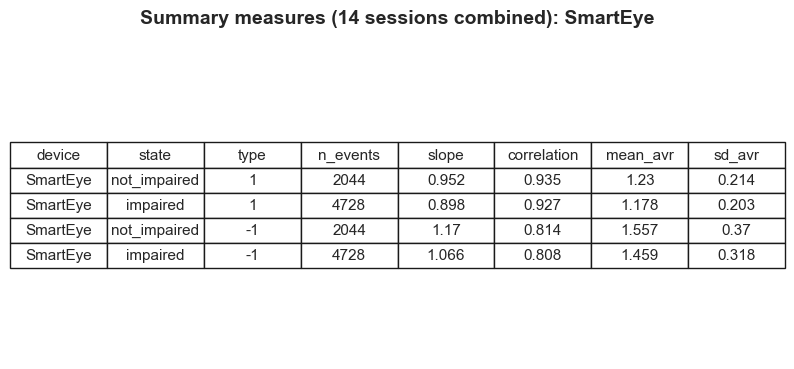

In [19]:
# ---------------- sm stat plot ----------------

fig, ax = plt.subplots(figsize=(10, 4))

# Turn off axes (equivalent to geom_blank + theme cleanup)
ax.axis("off")

# Create table
table = ax.table(
    cellText=sm_sm_stat3.values,
    colLabels=sm_sm_stat3.columns,
    loc="center",
    cellLoc="center"
)

# Formatting similar to ttheme_default(base_size = 11)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.5)

# Title
plt.title(
    f"Summary measures ({n_session_final} sessions combined): SmartEye",
    fontsize=14,
    fontweight="bold",
    loc="center",
    pad=20
)

plt.show()


C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values t

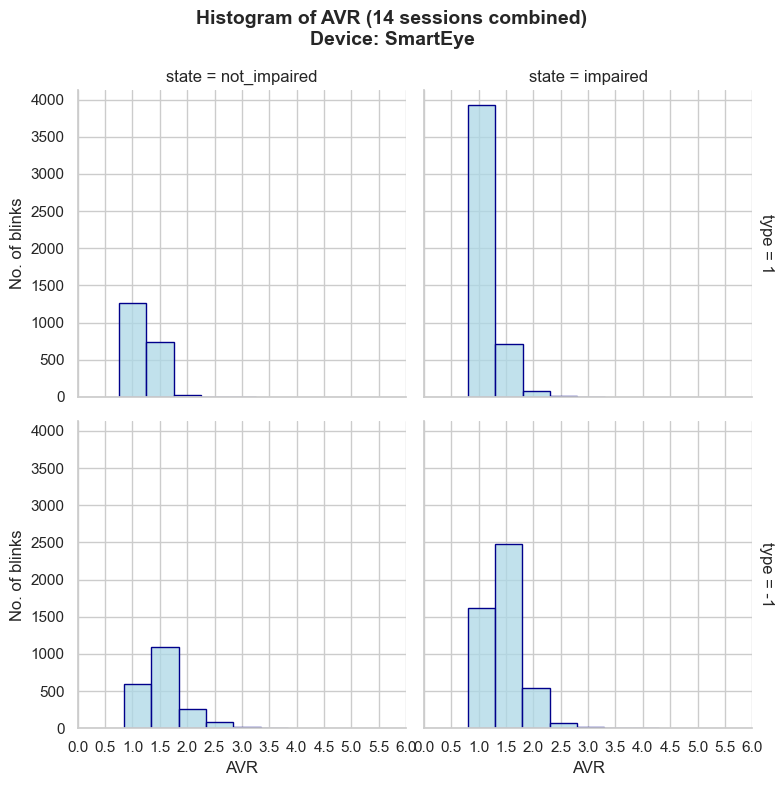

In [20]:
# ---------------- histogram of AVR ----------------

# Set style similar to theme_bw()
sns.set_style("whitegrid")

# Create faceted histogram
g = sns.FacetGrid(
    sm_sm_dt,
    row="type",
    col="state",
    margin_titles=True,
    height=4,
    aspect=1
)

# Plot histogram
g.map_dataframe(
    sns.histplot,
    x="avr",
    binwidth=0.5,
    color="lightblue",
    edgecolor="darkblue"
)

# Axis settings
g.set(
    xlim=(0, 6),
    xlabel="AVR",
    ylabel="No. of blinks"
)

# Set x-axis ticks
for ax in g.axes.flat:
    ax.set_xticks(np.arange(0, 6.5, 0.5))

# Overall title
g.fig.suptitle(
    f"Histogram of AVR ({n_session_final} sessions combined)\nDevice: SmartEye",
    fontsize=14,
    fontweight="bold",
    ha="center"
)

# Adjust layout for title spacing
g.fig.subplots_adjust(top=0.88)

plt.show()


<font color = 'yellow'> Vipul: Clearly number of blinks have reduced with Smart Eye. Also shift in AVR for type = -1

## Video JDS model for SmartEye

Compared to glasses JDS algorithm, some variables can not be measured accurately form video signals. Any variable associated with DOQ, Saccades, Long Closures are not available for video data. The following variables are used in the linear model:

In [21]:
indep_var = ["LnMeanPositiveZCI",
                  "LnStdDevPositiveZCI",
                  "LnMeanNegativeZCI" ,
                  "LnStdDevNegativeZCI", 
                  "LnMeanNegativeIED", 
                  "LnStdDevNegativeIED",     
                  "LnMeanBECD",
                  "LnStdDevBECD",
                  "LnMeanBTD",
                  "LnStdDevBTD",
                  "LnMeanPositiveAVR",
                  "LnStdDevPositiveAVR",
                  "LnMeanNegativeAVR",
                  "LnStdDevNegativeAVR", 
                  "LnMeanAVRProduct", 
                  "LnStdDevAVRProduct"]

The same difinition/criteria are used to define blink\_correct\_shape for both glasses and video blinks. These criteria are defined based on glasses blinks characteristics. <font color = 'red'> What criterias?


To develop new weightings for video JDS model, two appproaches are used:


- Linear model: Since there is no data associated with driving condition, the component identified by JDSB is irrelevent here. The Raw JDS is nothing but the JDSA itself. JDSA is fitted using stepwise forward-backward variable selection method. 

- Logistic model: using the original class labels of alert and drowsy minutes, a model is build to predict the probability of being in a class. 


In [22]:
import os
import glob
import pandas as pd

# ---------------- Store summary stats from SmartEye ----------------
sm_ss = []

# ---------------- Store JDS score from glasses ----------------
gl_score = []

# ---------------- Read summary stat files ----------------
for s in range(len(sm_session_final)):

    session_path = sm_session_final[s]
    session_name = os.path.basename(session_path)

    # ---- SmartEye summary stats ----
    sm_files = glob.glob(
        os.path.join(session_path, "smarteye", "*summary_stats.csv")
    )

    if sm_files:
        ss = pd.read_csv(sm_files[0])
        ss["device"] = "SmartEye"
        ss["session"] = session_name
        sm_ss.append(ss)

    # ---- Glasses JDS stats ----
    gl_files = glob.glob(
        os.path.join(session_path, "glasses", "*jds_stats.csv")
    )

    if gl_files:
        gl = pd.read_csv(gl_files[0])
        gl["device"] = "Glasses"
        gl["session"] = session_name
        gl_score.append(gl)

In [23]:
# ---------------- combine data for all sessions ----------------
# Equivalent of do.call(rbind, sm_ss)
sm_mdt = pd.concat(sm_ss, ignore_index=True)

# ---------------- add JTV responses ----------------
sm_mdt = sm_mdt.merge(
    sm_jtv_all[["session", "JTV_percentage_20min"]],
    on="session",
    how="right"
)

# ---------------- add n_lapses responses ----------------
sm_mdt = sm_mdt.merge(
    sm_jtv_pm_lapsing_all[["session", "window", "n_stimuli", "n_lapses"]],
    on=["session", "window"],
    how="right"
)

# ---------------- add state20min (impaired if JTV > 5%) ----------------
sm_mdt["state20min"] = np.where(
    sm_mdt["JTV_percentage_20min"] > 5,
    "impaired",
    "not_impaired"
)

sm_mdt["state20min"] = pd.Categorical(
    sm_mdt["state20min"],
    categories=["not_impaired", "impaired"],
    ordered=True
)

# ---------------- add lapsing_minute (n_lapses > 0) ----------------
sm_mdt["lapsing_minute"] = np.where(
    sm_mdt["n_lapses"] > 0,
    "yes",
    "no"
)

sm_mdt["lapsing_minute"] = pd.Categorical(
    sm_mdt["lapsing_minute"],
    categories=["no", "yes"],
    ordered=True
)

# ---------------- remove NA ----------------
sm_mdt = sm_mdt.dropna()


In [24]:
# ---------------- combined glasses score for all sessions ----------------
# Equivalent of do.call(rbind, gl_score)
gl_score_all = pd.concat(gl_score, ignore_index=True)

# ---------------- add JTV responses ----------------
gl_score_all = gl_score_all.merge(
    sm_jtv_all[["session", "JTV_percentage_20min"]],
    on="session",
    how="right"
)

# ---------------- add n_lapses responses ----------------
gl_score_all = gl_score_all.merge(
    sm_jtv_pm_lapsing_all[["session", "window", "n_stimuli", "n_lapses"]],
    on=["session", "window"],
    how="right"
)

# ---------------- add state20min (impaired if JTV > 5%) ----------------
gl_score_all["state20min"] = np.where(
    gl_score_all["JTV_percentage_20min"] > 5,
    "impaired",
    "not_impaired"
)

gl_score_all["state20min"] = pd.Categorical(
    gl_score_all["state20min"],
    categories=["not_impaired", "impaired"],
    ordered=True
)

# ---------------- add lapsing_minute (n_lapses > 0) ----------------
gl_score_all["lapsing_minute"] = np.where(
    gl_score_all["n_lapses"] > 0,
    "yes",
    "no"
)

gl_score_all["lapsing_minute"] = pd.Categorical(
    gl_score_all["lapsing_minute"],
    categories=["no", "yes"],
    ordered=True
)

# ---------------- remove NA ----------------
gl_score_all = gl_score_all.dropna()



### Linear model: SmartEye video {Video JDS model for SmartEye using JTV\_percentage\_20min as state of impairment}

A video model is derived using the per minute observations. The JTV\_percentage\_20min is used to define the state of impairment. Every valid minute in a recording is labelled as  not\_impaired if the JTV\_percetage\_20min is below $5\%$ and impaired otherwise. 

To facilitate the linear model, all the not\_impaired observaitons are coded as -4 and al lthe impaired observaions are coded as 9. Important variables are selected using the stepwsie forward-backward algorithm. 



In [25]:
# jds code: alert = -1 and drowsy = 2
sm_mdt["state20min_code"] = -4
sm_mdt.loc[sm_mdt["state20min"] == "impaired", "state20min_code"] = 9

In [26]:
missing_cols = [col for col in indep_var if col not in sm_mdt.columns]
print("Missing columns:", missing_cols)


Missing columns: ['LnMeanPositiveZCI', 'LnStdDevPositiveZCI', 'LnMeanNegativeZCI', 'LnStdDevNegativeZCI', 'LnMeanNegativeIED', 'LnStdDevNegativeIED', 'LnMeanBECD', 'LnStdDevBECD', 'LnMeanBTD', 'LnStdDevBTD', 'LnMeanPositiveAVR', 'LnStdDevPositiveAVR', 'LnMeanNegativeAVR', 'LnStdDevNegativeAVR', 'LnMeanAVRProduct', 'LnStdDevAVRProduct']


In [27]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# ---------------- Prepare Data ----------------
# Assume indep_var is a list of predictor names
sm_mdt.columns   = sm_mdt.columns.str.strip()  # Remove leading/trailing whitespace from column names
X = sm_mdt[indep_var].copy()
y = sm_mdt["state20min_code"].values

# Ensure numeric and drop rows with NA
X = X.apply(pd.to_numeric, errors='coerce')
Xy = pd.concat([X, pd.Series(y, name="state20min_code")], axis=1).dropna()
X = Xy[indep_var]
y = Xy["state20min_code"].values

# ---------------- Backward elimination ----------------
def backward_elimination(X, y, sl=0.05):
    """Perform backward elimination based on p-values using statsmodels."""
    X_be = X.copy()
    while True:
        X_be_const = sm.add_constant(X_be)
        model = sm.OLS(y, X_be_const).fit()
        pvalues = model.pvalues.drop("const")
        max_pval = pvalues.max()
        if max_pval > sl:
            remove_var = pvalues.idxmax()
            print(f"Dropping {remove_var} with p-value {max_pval:.4f}")
            X_be = X_be.drop(columns=[remove_var])
        else:
            break
    return X_be.columns.tolist()

# Apply backward elimination
predictors_kept = backward_elimination(X, y, sl=0.05)
print("Predictors kept after backward elimination:", predictors_kept)

# ---------------- Final model using sklearn ----------------
X_final = X[predictors_kept].values
lr = LinearRegression()
lr.fit(X_final, y)

# ---------------- Coefficients ----------------
coef_df = pd.DataFrame({
    "Predictor": ["Intercept"] + predictors_kept,
    "Coefficient": [lr.intercept_] + list(lr.coef_)
})


Dropping LnMeanBTD with p-value 0.9555
Dropping LnMeanAVRProduct with p-value 0.5269
Dropping LnStdDevNegativeZCI with p-value 0.4853
Dropping LnStdDevBECD with p-value 0.3574
Dropping LnStdDevPositiveAVR with p-value 0.0649
Dropping LnStdDevPositiveZCI with p-value 0.2980
Dropping LnStdDevAVRProduct with p-value 0.0579
Dropping LnStdDevNegativeAVR with p-value 0.1229
Dropping LnMeanNegativeAVR with p-value 0.0589
Dropping LnMeanNegativeZCI with p-value 0.1237
Predictors kept after backward elimination: ['LnMeanPositiveZCI', 'LnMeanNegativeIED', 'LnStdDevNegativeIED', 'LnMeanBECD', 'LnStdDevBTD', 'LnMeanPositiveAVR']


In [28]:
# ---------------- Create a "final model" object equivalent ----------------
class FinalLinearModel:
    def __init__(self, model, predictors, intercept, coef, X_final):
        self.model = model             # sklearn.LinearRegression object
        self.predictors_kept = predictors
        self.intercept = intercept
        self.coef = coef
        self.X_final = X_final         # predictor data used to fit the model

    def summary(self):
        # Build a table similar to statsmodels
        return pd.DataFrame({
            "Predictor": ["Intercept"] + list(self.predictors_kept),
            "Coefficient": [self.intercept] + list(self.coef)
        })

# ---------------- Instantiate final model ----------------
state20min_final_mod = FinalLinearModel(
    model=lr,
    predictors=predictors_kept,
    intercept=lr.intercept_,
    coef=lr.coef_,
    X_final=X_final
)

## The final model selected for JDS using forward-backward variable elimination is   ####
# ---------------- Show summary ----------------
print(state20min_final_mod.summary())


             Predictor  Coefficient
0            Intercept   -62.595680
1    LnMeanPositiveZCI    20.013812
2    LnMeanNegativeIED    -5.639843
3  LnStdDevNegativeIED     2.890512
4           LnMeanBECD     3.039893
5          LnStdDevBTD    -2.373545
6    LnMeanPositiveAVR   -30.639658


In [29]:
# ---------------- Prepare predictor data for prediction ----------------
X_pred = sm_mdt[state20min_final_mod.predictors_kept].copy()
X_pred = X_pred.apply(pd.to_numeric, errors='coerce')
X_pred = X_pred.dropna()  # Drop any rows with missing predictor values

# ---------------- Predict raw JDS values ----------------
sm_mdt.loc[X_pred.index, "state20min_jds"] = state20min_final_mod.model.predict(X_pred)

# ---------------- Truncate values to [0, 10] ----------------
sm_mdt["state20min_jds"] = sm_mdt["state20min_jds"].clip(lower=0, upper=10)


C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a lengt

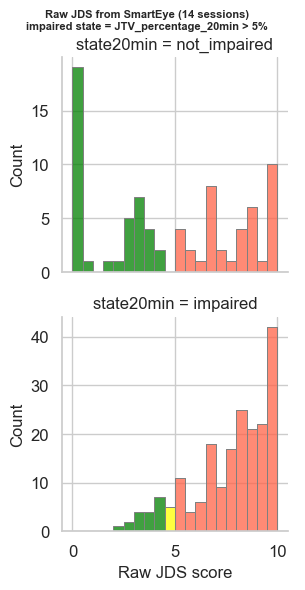

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- Prepare data ----------------
plot_dt = sm_mdt[["session", "state20min", "state20min_jds"]].copy()

# Assign colors based on JDS thresholds
def jds_color(jds):
    if jds > 5:
        return "tomato"
    elif jds < 4.5:
        return "green"
    else:
        return "yellow"

plot_dt["fcolor"] = plot_dt["state20min_jds"].apply(jds_color)
plot_dt["fcolor"] = pd.Categorical(plot_dt["fcolor"], categories=["green","yellow","tomato"], ordered=True)

# ---------------- Plot ----------------
g = sns.FacetGrid(plot_dt, col="state20min", col_wrap=1, sharex=True, sharey=False)
g.map_dataframe(
    sns.histplot,
    x="state20min_jds",
    bins=np.arange(0, 10.5, 0.5),
    hue="fcolor",
    palette={"green":"green","yellow":"yellow","tomato":"tomato"},
    multiple="stack",
    edgecolor="grey"
)

# Remove legend
g.add_legend(title="")
for ax in g.axes.flat:
    ax.set_xlabel("Raw JDS score")
    ax.set_ylabel("Count")
    ax.tick_params(axis='both', which='major', labelsize=12)
    
# Add title
plt.subplots_adjust(top=0.9)
g.fig.suptitle(
    f"Raw JDS from {model_device} ({n_session_final} sessions)\nimpaired state = JTV_percentage_20min > 5%", 
    fontsize=8, fontweight='bold'
)

plt.show()


C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a lengt

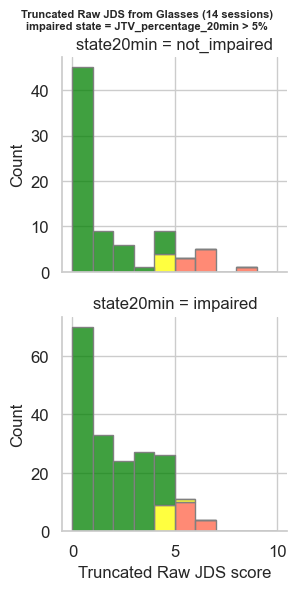

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- Prepare data ----------------
gl_score_all.columns = [col.strip() for col in gl_score_all.columns]
gl_dt = gl_score_all[["session", "state20min", "jds_raw"]].copy()

# Truncate values to [0, 10]
gl_dt["jds_raw"] = gl_dt["jds_raw"].astype(float).clip(lower=0, upper=10)

# Assign colors
def jds_color(jds):
    if jds > 5:
        return "tomato"
    elif jds < 4.5:
        return "green"
    else:
        return "yellow"

gl_dt["fcolor"] = gl_dt["jds_raw"].apply(jds_color)
gl_dt["fcolor"] = pd.Categorical(gl_dt["fcolor"], categories=["green","yellow","tomato"], ordered=True)

# ---------------- Plot ----------------
g = sns.FacetGrid(gl_dt, col="state20min", col_wrap=1, sharex=True, sharey=False)
g.map_dataframe(
    sns.histplot,
    x="jds_raw",
    bins=np.arange(0, 11, 1),   # binwidth = 1 like R
    hue="fcolor",
    palette={"green":"green","yellow":"yellow","tomato":"tomato"},
    multiple="stack",
    edgecolor="grey"
)

# Remove legend
g.add_legend(title="")
for ax in g.axes.flat:
    ax.set_xlabel("Truncated Raw JDS score")
    ax.set_ylabel("Count")
    ax.tick_params(axis='both', which='major', labelsize=12)

# Add title
plt.subplots_adjust(top=0.9)
g.fig.suptitle(
    f"Truncated Raw JDS from Glasses ({n_session_final} sessions)\n"
    "impaired state = JTV_percentage_20min > 5%", 
    fontsize=8, fontweight='bold'
)

plt.show()


Vipul: Raw jds is comparatively lower than predicted jds by the model above

#### Relationship between other variables

In [32]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# # ---------------- Combine sm_dt list into one DataFrame ----------------
# # sm_dt_df = pd.concat(sm_mdt, ignore_index=True)

# # ---------------- Filter for SmartEye sessions ----------------
# sm_vid_blink_dt = sm_mdt_df[
#     (sm_mdt_df["device"] == "SmartEye") &
#     (sm_mdt_df["session"].isin([s for s in sm_session_final]))
# ].copy()

# # Ensure 'state' is categorical with the same levels
# sm_vid_blink_dt["state"] = pd.Categorical(sm_vid_blink_dt["state"], categories=["not_impaired", "impaired"])

# # Filter for Positive type (type == 1)
# sm_pos = sm_vid_blink_dt[sm_vid_blink_dt["type"] == 1]

# # ---------------- Plot ----------------
# g = sns.FacetGrid(sm_pos, col="device", row="state", margin_titles=True, sharex=False, sharey=False)
# g.map_dataframe(
#     sns.scatterplot,
#     x="btd",
#     y="zci",
#     color="blue",
#     edgecolor="w",
#     s=50
# )

# # Set log scales
# for ax in g.axes.flat:
#     ax.set_xscale("log")
#     ax.set_yscale("log")
#     ax.set_xlabel("log(BTD)")
#     ax.set_ylabel("log(Positive ZCI)")

# # Add title
# plt.subplots_adjust(top=0.9)
# g.fig.suptitle("Relationship between Pos ZCI and BTD\n(all sessions combined)", fontsize=14, fontweight='bold')

# sns.despine()
# plt.show()


### Linear video model using lapsing minutes {Video JDS for SmartEye using lapsing minute}

In [33]:
import pandas as pd
import numpy as np

# ---------------- Initialize ----------------
sm_mdt["statelapse"] = np.nan

# ---------------- Assign combined states ----------------
sm_mdt.loc[
    (sm_mdt["state20min"] == "not_impaired") & (sm_mdt["lapsing_minute"] == "no"),
    "statelapse"
] = "not_impaired_not_lapsing"

sm_mdt.loc[
    (sm_mdt["state20min"] == "not_impaired") & (sm_mdt["lapsing_minute"] == "yes"),
    "statelapse"
] = "not_impaired_lapsing"

sm_mdt.loc[
    (sm_mdt["state20min"] == "impaired") & (sm_mdt["lapsing_minute"] == "no"),
    "statelapse"
] = "impaired_not_lapsing"

sm_mdt.loc[
    (sm_mdt["state20min"] == "impaired") & (sm_mdt["lapsing_minute"] == "yes"),
    "statelapse"
] = "impaired_lapsing"

# Convert to categorical with specified order (like R factor levels)
sm_mdt["statelapse"] = pd.Categorical(
    sm_mdt["statelapse"],
    categories=["not_impaired_not_lapsing", "not_impaired_lapsing",
                "impaired_not_lapsing", "impaired_lapsing"],
    ordered=True
)

# ---------------- Assign statelapse codes ----------------
sm_mdt["statelapse_code"] = 100  # default

sm_mdt.loc[sm_mdt["statelapse"] == "not_impaired_not_lapsing", "statelapse_code"] = -1
sm_mdt.loc[sm_mdt["statelapse"] == "impaired_lapsing", "statelapse_code"] = 9

# ---------------- Subset data ----------------
sm_mdt2 = sm_mdt[
    sm_mdt["statelapse"].isin(["not_impaired_not_lapsing", "impaired_lapsing"])
].copy()


C:\Users\VJain\AppData\Local\Temp\ipykernel_10608\1615831613.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'not_impaired_not_lapsing' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  sm_mdt.loc[


In [34]:
import pandas as pd

# Contingency table
table_dt = pd.crosstab(sm_mdt["state20min"], sm_mdt["lapsing_minute"])

# Print table
print(table_dt)

lapsing_minute   no  yes
state20min              
not_impaired     71   13
impaired        114   96


In [35]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import pandas as pd

# ------------------- Prepare data -------------------
# sm_mdt2 is already the subset with statelapse_code
X = sm_mdt2[indep_var].copy()   # predictors
X = X.apply(pd.to_numeric, errors="coerce")  # convert all to numeric
y = pd.to_numeric(sm_mdt2["statelapse_code"], errors="coerce")

# Drop rows with NaN
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

# Add intercept column for statsmodels p-values
X_sm = sm.add_constant(X)

# ------------------- Fit full model -------------------
full_model = sm.OLS(y, X_sm).fit()

# ------------------- Drop NA coefficients -------------------
valid_predictors = full_model.params.dropna().index.tolist()
if "const" in valid_predictors:
    valid_predictors.remove("const")

X_valid = sm.add_constant(X[valid_predictors])
full_model_valid = sm.OLS(y, X_valid).fit()

# ------------------- Backward elimination -------------------
def backward_elimination(X, y, sl=0.05):
    """
    Backward elimination based on p-values.
    """
    X_be = X.copy()
    X_be = sm.add_constant(X_be)
    predictors = X_be.columns.tolist()
    
    while True:
        model = sm.OLS(y, X_be).fit()
        pvalues = model.pvalues.drop("const")
        max_pval = pvalues.max()
        if max_pval > sl:
            remove_var = pvalues.idxmax()
            predictors.remove(remove_var)
            X_be = X_be[predictors]
        else:
            break
    return [p for p in predictors if p != "const"]

predictors_kept = backward_elimination(X[valid_predictors], y, sl=0.05)

# ------------------- Fit final model -------------------
X_final = sm.add_constant(X[predictors_kept])
statelapses_final_mod = sm.OLS(y, X_final).fit()

# ------------------- Calculate statelapse_jds -------------------
# Make sure we use numeric columns from full sm_mdt
X_all = sm_mdt[predictors_kept].apply(pd.to_numeric, errors="coerce")
X_all = sm.add_constant(X_all, has_constant='add')
sm_mdt["statelapse_jds"] = statelapses_final_mod.predict(X_all)

# Truncate between 0 and 10
sm_mdt["statelapse_jds"] = sm_mdt["statelapse_jds"].clip(lower=0, upper=10)

# ------------------- Print summary -------------------
print(statelapses_final_mod.summary())


                            OLS Regression Results                            
Dep. Variable:        statelapse_code   R-squared:                       0.549
Model:                            OLS   Adj. R-squared:                  0.532
Method:                 Least Squares   F-statistic:                     31.29
Date:                Wed, 11 Feb 2026   Prob (F-statistic):           2.09e-24
Time:                        14:07:10   Log-Likelihood:                -420.74
No. Observations:                 161   AIC:                             855.5
Df Residuals:                     154   BIC:                             877.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   3.6178    

C:\Users\VJain\AppData\Local\Temp\ipykernel_10608\1465617775.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  facets = plot_dt.groupby(["state20min","lapsing_minute"])


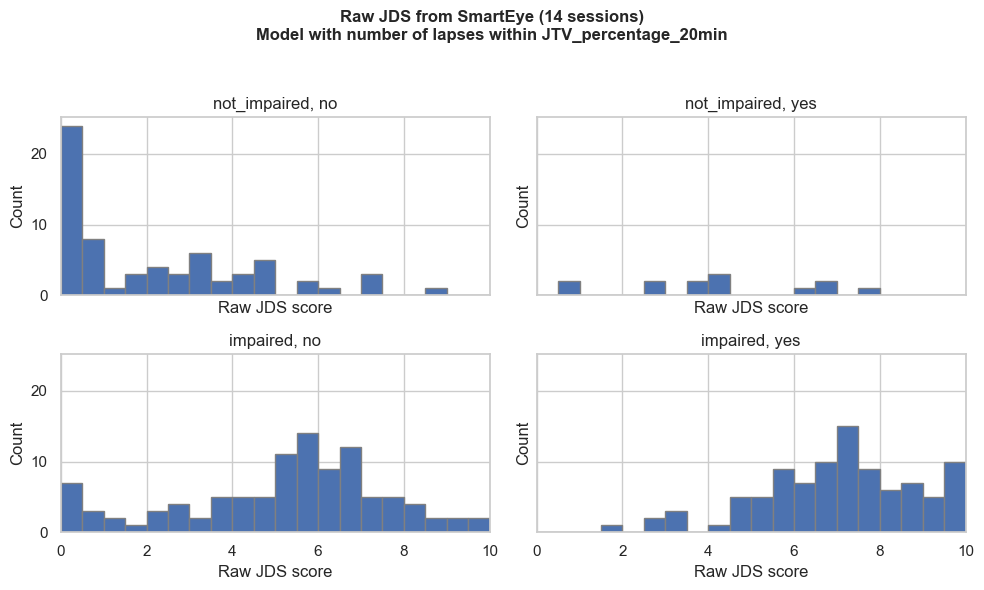

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ------------------- Prepare data -------------------
plot_dt = sm_mdt[["session","state20min","lapsing_minute","statelapse_jds"]].copy()

# Assign colors
plot_dt["fcolor"] = np.where(
    plot_dt["statelapse_jds"] > 5, "tomato",
    np.where(plot_dt["statelapse_jds"] < 4.5, "green", "yellow")
)

# ------------------- Facet by state20min + lapsing_minute -------------------
facets = plot_dt.groupby(["state20min","lapsing_minute"])

n_facets = len(facets)
n_cols = 2  # adjust layout
n_rows = int(np.ceil(n_facets / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows*3), sharex=True, sharey=True)
axes = axes.flatten()

for i, ((state, lapsing), data) in enumerate(facets):
    ax = axes[i]
    # Histogram with 0.5 bin width
    bins = np.arange(0, 10.5, 0.5)
    ax.hist(data["statelapse_jds"], bins=bins, edgecolor="grey")
    ax.set_title(f"{state}, {lapsing}", fontsize=12)
    ax.set_xlim(0, 10)
    ax.set_xlabel("Raw JDS score")
    ax.set_ylabel("Count")

# Remove empty subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(f"Raw JDS from {model_device} ({n_session_final} sessions)\nModel with number of lapses within JTV_percentage_20min",
             fontsize=12, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [37]:
import numpy as np
import pandas as pd

# bin predicted JDS score
bin_low = np.arange(0, 10, 1)
bin_up = np.concatenate([np.arange(0.9, 9, 1), [10]])

# classify them according to the bin
sm_mdt["statelapsejds_bin"] = pd.cut(
    sm_mdt["statelapse_jds"].round(1),
    bins=np.concatenate([[0], bin_up]),
    right=True,
    include_lowest=True,
    labels=list(range(1, 11))
)

sm_mdt["statelapsejds_bin_name"] = sm_mdt["statelapsejds_bin"]

# calculate percentage of minute with at least one lapse that falls within each score group
rr_jds = (
    sm_mdt
        .groupby("statelapsejds_bin_name")
        .agg(
            total_minute=("n_lapses", "size"),
            n_lapsing_minute=("n_lapses", lambda x: (x > 0).sum())
        )
        .reset_index()
)

rr_jds["lapsing_minute_perc"] = (
    100 * rr_jds["n_lapsing_minute"] / rr_jds["total_minute"]
).round(1)



C:\Users\VJain\AppData\Local\Temp\ipykernel_10608\2433956415.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("statelapsejds_bin_name")


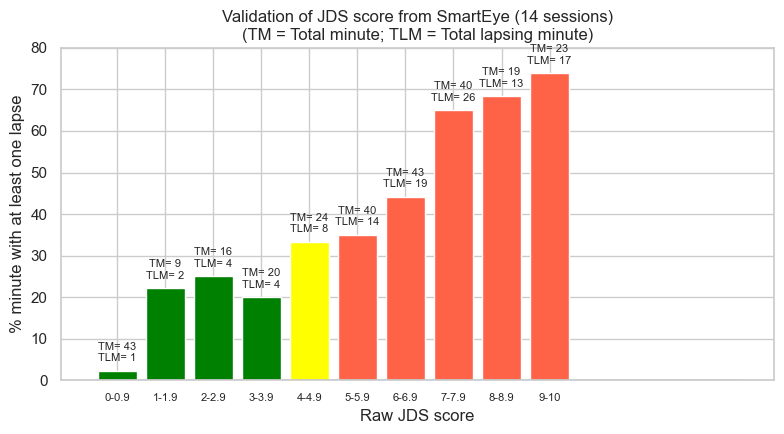

In [38]:
import matplotlib.pyplot as plt
import numpy as np

bardt = rr_jds

# calculate top of each bar to print text
bartopText_y = bardt["lapsing_minute_perc"] + 7

# bar positions (equivalent to barplot return values in R)
score_plot1 = np.arange(len(bardt))

# bar plot
plt.figure(figsize=(8, 4.5))
plt.bar(
    score_plot1,
    bardt["lapsing_minute_perc"],
    color=["green", "green", "green", "green",
           "yellow",
           "tomato", "tomato", "tomato", "tomato", "tomato"]
)

plt.ylim(0, 80)
plt.xlabel("Raw JDS score")
plt.ylabel("% minute with at least one lapse")
plt.title(
    f"Validation of JDS score from {model_device} ({n_session_final} sessions)\n"
    "(TM = Total minute; TLM = Total lapsing minute)",
    fontweight="normal"
)

# x-axis baseline (like lines() in R)
plt.hlines(
    y=0,
    xmin=-0.5,
    xmax=len(bardt) + 3,
    linewidth=1
)

# text on top of each bar
for x, y, tm, tlm in zip(
    score_plot1,
    bartopText_y,
    bardt["total_minute"],
    bardt["n_lapsing_minute"]
):
    plt.text(
        x,
        y,
        f"TM= {tm}\nTLM= {tlm}",
        ha="center",
        va="top",
        fontsize=8
    )

# x-axis labels
plt.xticks(
    score_plot1,
    ["0-0.9", "1-1.9", "2-2.9", "3-3.9", "4-4.9",
     "5-5.9", "6-6.9", "7-7.9", "8-8.9", "9-10"],
    fontsize=8
)

plt.tight_layout()
plt.show()


In [39]:
# Combine last groups together (9 & 10 -> 8+)
rr_jds_8plus = (
    rr_jds[rr_jds["statelapsejds_bin_name"].isin([9, 10])]
        .agg(
            total_minute=("total_minute", "sum"),
            n_lapsing_minute=("n_lapsing_minute", "sum")
        )
        .reset_index(drop=True)
)

rr_jds_8plus["lapsing_minute_perc"] = (
    100 * rr_jds_8plus["n_lapsing_minute"] / rr_jds_8plus["total_minute"]
).round(1)

rr_jds_8plus["statelapsejds_bin_name"] = "8+"

# rbind equivalent
rr_jds_comb = pd.concat(
    [
        rr_jds[rr_jds["statelapsejds_bin_name"].isin(range(1, 9))],
        rr_jds_8plus
    ],
    ignore_index=True
)


## Video model with 8 session: A comparison with Visage\_SmartEye video model

In [40]:
# session names
sm_8ses_in = [
    "20160817_020230_tm", "20160819_0230_hz",
    "20160819_0300_tm", "20160819_0326_hz",
    "20160824_0200_sm", "20160824_0230_hz",
    "20160824_0300_sm", "20160824_0330_hz"
]

# model data
sm_8ses_mdt = sm_mdt[sm_mdt["session"].isin(sm_8ses_in)].copy()

# blink correct shape data
sm_dt_8ses = sm_dt_final[sm_dt_final["session"].isin(sm_8ses_in)].copy()

# number of sessions
len(sm_8ses_in)


8

In [41]:
cx = (sm_dt_8ses["maxvel"].min(), sm_dt_8ses["maxvel"].max())
cy = (sm_dt_8ses["maxamp"].min(), sm_dt_8ses["maxamp"].max())

# subset data
sm_gl_dt = sm_dt_8ses[sm_dt_8ses["device"] == "Glasses"].copy()

# factor / categorical ordering (equivalent to factor(level=...))
sm_gl_dt["type"] = pd.Categorical(
    sm_gl_dt["type"],
    categories=[1, -1],
    ordered=True
)


C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


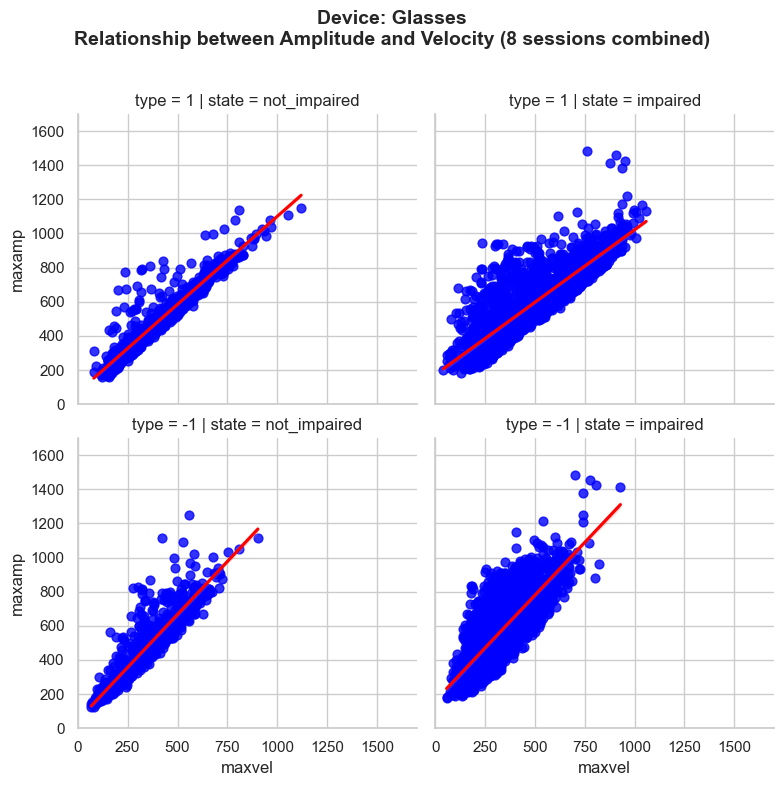

In [42]:
g = sns.lmplot(
    data=sm_gl_dt,
    x="maxvel",
    y="maxamp",
    col="state",
    row="type",
    scatter_kws={"color": "blue", "s": 40},
    line_kws={"color": "red"},
    height=4,
    aspect=1
)

# axis limits (match ggplot)
g.set(
    xlim=(0, 1700),
    ylim=(0, 1700)
)

# labels and title
g.set_axis_labels("maxvel", "maxamp")

plt.subplots_adjust(top=0.85)
g.fig.suptitle(
    "Device: Glasses\nRelationship between Amplitude and Velocity (8 sessions combined)",
    fontsize=14,
    fontweight="bold",
    ha="center"
)

# ggplot-like theme
sns.set_style("whitegrid")

plt.show()


In [43]:
rows = []

for (state, type_), df in sm_gl_dt.groupby(["state", "type"]):
    # number of events
    n_events = len(df)

    # linear model: maxamp ~ maxvel
    X = df[["maxvel"]].values
    y = df["maxamp"].values
    lm = LinearRegression().fit(X, y)
    slope = round(lm.coef_[0], 3)

    # correlation
    corr, _ = pearsonr(df["maxamp"], df["maxvel"])
    correlation = round(corr, 3)

    rows.append({
        "state": state,
        "type": type_,
        "n_events": n_events,
        "slope": slope,
        "correlation": correlation
    })

sm_gl_stat1 = (
    pd.DataFrame(rows)
      .sort_values("type")
      .reset_index(drop=True)
)


C:\Users\VJain\AppData\Local\Temp\ipykernel_10608\2625154837.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (state, type_), df in sm_gl_dt.groupby(["state", "type"]):


In [44]:
sm_gl_stat2 = (
    sm_gl_dt
        .groupby(["state", "type"])
        .agg(
            mean_avr=("avr", lambda x: round(x.mean(), 3)),
            sd_avr=("avr", lambda x: round(x.std(), 3))
        )
        .reset_index()
        .sort_values("type")
)


C:\Users\VJain\AppData\Local\Temp\ipykernel_10608\128066911.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["state", "type"])


In [45]:
sm_gl_stat3 = (
    sm_gl_stat1
        .merge(sm_gl_stat2, on=["state", "type"], how="right")
)

sm_gl_stat3.insert(0, "device", "Glasses")


In [46]:
sm_gl_stat3

,device,state,type,n_events,slope,correlation,mean_avr,sd_avr
0,Glasses,not_impaired,1,1003,1.030,0.952,1.254,0.246
1,Glasses,impaired,1,2404,0.849,0.857,1.293,0.470
2,Glasses,not_impaired,-1,1003,1.239,0.922,1.434,0.263
3,Glasses,impaired,-1,2404,1.235,0.766,1.793,0.529


C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1057: FutureWarning: The default of observed=Fa

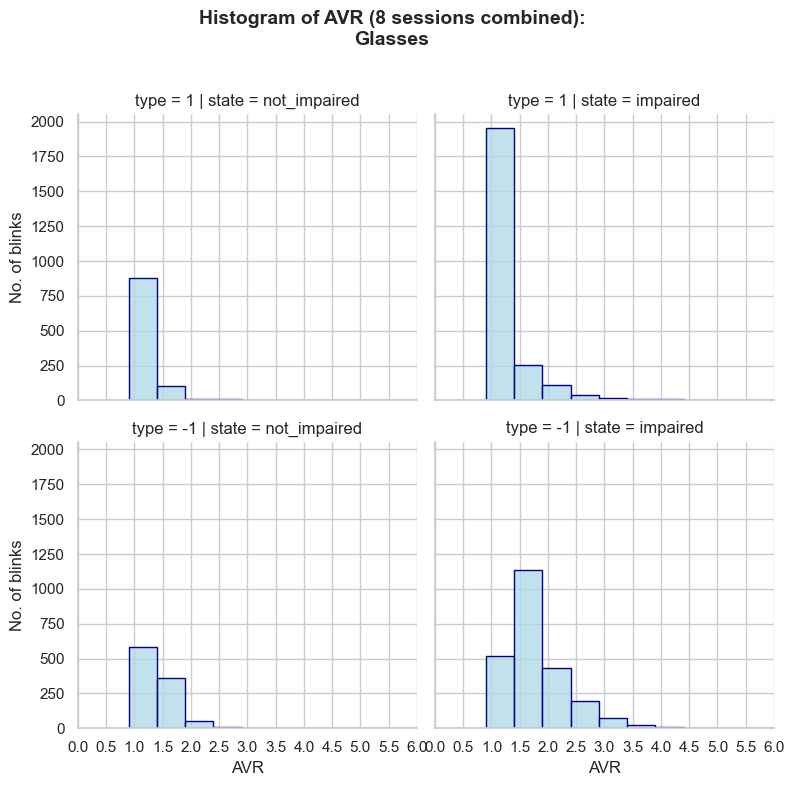

In [47]:
# faceted histogram
g = sns.displot(
    data=sm_gl_dt,
    x="avr",
    col="state",
    row="type",
    binwidth=0.5,
    color="lightblue",
    edgecolor="darkblue",
    height=4,
    aspect=1
)

# axis limits and breaks
g.set(
    xlim=(0, 6),
    xticks=np.arange(0, 6.5, 0.5)
)

# labels
g.set_axis_labels("AVR", "No. of blinks")

# title
plt.subplots_adjust(top=0.85)
g.fig.suptitle(
    "Histogram of AVR (8 sessions combined):\nGlasses",
    fontsize=14,
    fontweight="bold",
    ha="center"
)

# theme_bw-like styling
sns.set_style("whitegrid")

plt.show()


In [48]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt

# subset SmartEye device
sm_sm_dt = sm_dt_8ses[sm_dt_8ses["device"] == "SmartEye"].copy()

# factor / categorical ordering
sm_sm_dt["type"] = pd.Categorical(
    sm_sm_dt["type"],
    categories=[1, -1],
    ordered=True
)


C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


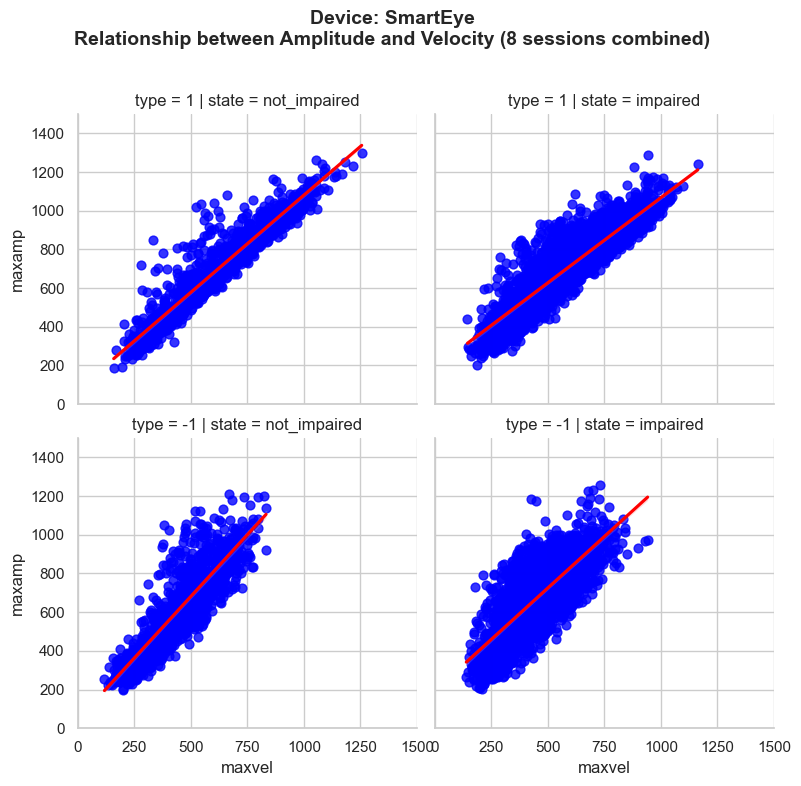

In [49]:
# faceted scatter + linear regression
g = sns.lmplot(
    data=sm_sm_dt,
    x="maxvel",
    y="maxamp",
    row="type",
    col="state",
    scatter_kws={"color": "blue", "s": 40},
    line_kws={"color": "red"},
    height=4,
    aspect=1
)

# axis limits
g.set(xlim=(0, 1500), ylim=(0, 1500))

# labels
g.set_axis_labels("maxvel", "maxamp")

# title
plt.subplots_adjust(top=0.85)
g.fig.suptitle(
    "Device: SmartEye\nRelationship between Amplitude and Velocity (8 sessions combined)",
    fontsize=14,
    fontweight="bold",
    ha="center"
)

sns.set_style("whitegrid")
plt.show()


In [50]:
rows = []

for (state, type_), df in sm_sm_dt.groupby(["state", "type"]):
    n_events = len(df)

    # linear regression
    X = df[["maxvel"]].values
    y = df["maxamp"].values
    lm = LinearRegression().fit(X, y)
    slope = round(lm.coef_[0], 3)

    # Pearson correlation
    corr, _ = pearsonr(df["maxamp"], df["maxvel"])
    correlation = round(corr, 3)

    rows.append({
        "state": state,
        "type": type_,
        "n_events": round(n_events, 3),
        "slope": slope,
        "correlation": correlation
    })

sm_sm_stat1 = pd.DataFrame(rows).sort_values("type").reset_index(drop=True)


C:\Users\VJain\AppData\Local\Temp\ipykernel_10608\2286808484.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (state, type_), df in sm_sm_dt.groupby(["state", "type"]):


In [51]:
sm_sm_stat2 = (
    sm_sm_dt
        .groupby(["state", "type"])
        .agg(
            mean_avr=("avr", lambda x: round(x.mean(), 3)),
            sd_avr=("avr", lambda x: round(x.std(), 3))
        )
        .reset_index()
        .sort_values("type")
)


C:\Users\VJain\AppData\Local\Temp\ipykernel_10608\683225030.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["state", "type"])


In [52]:
sm_sm_stat3 = (
    sm_sm_stat1
        .merge(sm_sm_stat2, on=["state", "type"], how="right")
)

sm_sm_stat3.insert(0, "device", "SmartEye")

sm_sm_stat3

,device,state,type,n_events,slope,correlation,mean_avr,sd_avr
0,SmartEye,not_impaired,1,1055,1.005,0.947,1.147,0.171
1,SmartEye,impaired,1,2516,0.880,0.900,1.214,0.227
2,SmartEye,not_impaired,-1,1055,1.274,0.863,1.385,0.265
3,SmartEye,impaired,-1,2516,1.063,0.766,1.530,0.355


C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1057: FutureWarning: The default of observed=Fa

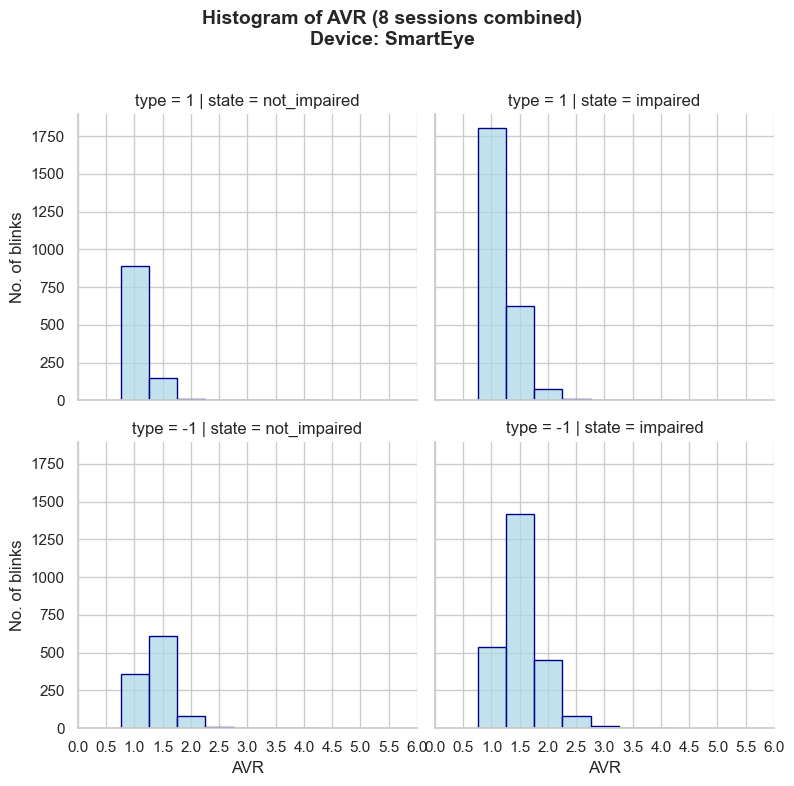

In [53]:

# faceted histogram
g = sns.displot(
    data=sm_sm_dt,
    x="avr",
    col="state",
    row="type",
    binwidth=0.5,
    color="lightblue",
    edgecolor="darkblue",
    height=4,
    aspect=1
)

# axis limits and breaks
g.set(
    xlim=(0, 6),
    xticks=np.arange(0, 6.5, 0.5)
)

# axis labels
g.set_axis_labels("AVR", "No. of blinks")

# title
plt.subplots_adjust(top=0.85)
g.fig.suptitle(
    "Histogram of AVR (8 sessions combined)\nDevice: SmartEye",
    fontsize=14,
    fontweight="bold",
    ha="center"
)

# ggplot2 theme_bw-like style
sns.set_style("whitegrid")

plt.show()


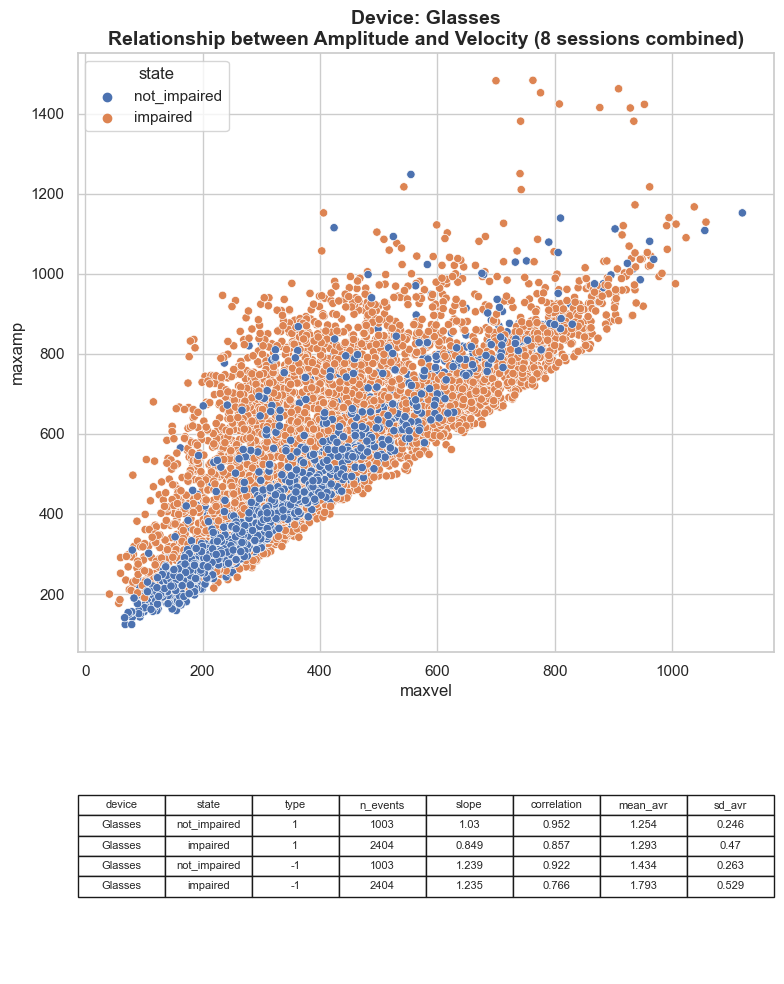

In [54]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    gridspec_kw={"height_ratios": [7, 3]},
    figsize=(8, 10)
)

# scatter plot on top
# sm_gl_plot is a FacetGrid (sns.lmplot/displot) → we can draw it separately
# For simplicity, if you already have saved figures, use .fig to embed or just recreate plots in axes

# Example: recreate in axes[0]
sns.scatterplot(
    data=sm_gl_dt,
    x="maxvel",
    y="maxamp",
    hue="state",  # optional
    ax=axes[0]
)
axes[0].set_title("Device: Glasses\nRelationship between Amplitude and Velocity (8 sessions combined)", fontsize=14, fontweight="bold")

# stat table / summary on bottom
# For table, you can use matplotlib table
axes[1].axis("off")  # hide axes
table_data = sm_gl_stat3.values
columns = sm_gl_stat3.columns
axes[1].table(cellText=table_data, colLabels=columns, loc="center", cellLoc="center")

plt.tight_layout()
plt.show()



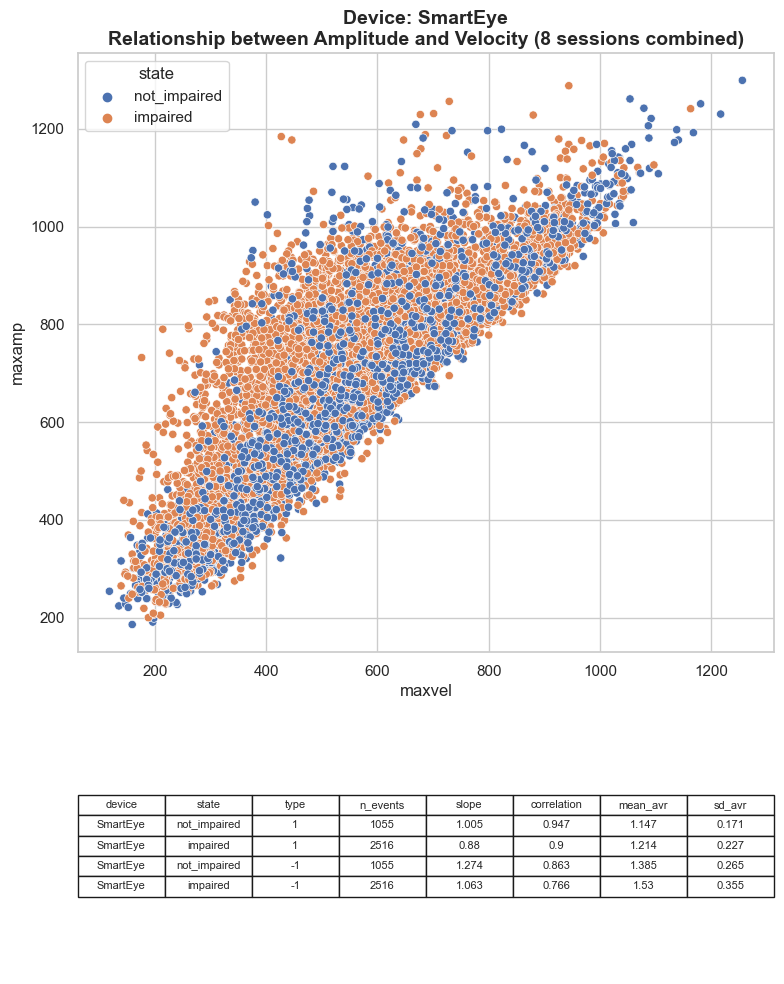

In [55]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    gridspec_kw={"height_ratios": [7, 3]},
    figsize=(8, 10)
)

# scatter plot
sns.scatterplot(
    data=sm_sm_dt,
    x="maxvel",
    y="maxamp",
    hue="state",  # optional
    ax=axes[0]
)
axes[0].set_title("Device: SmartEye\nRelationship between Amplitude and Velocity (8 sessions combined)", fontsize=14, fontweight="bold")

# stat table
axes[1].axis("off")
table_data = sm_sm_stat3.values
columns = sm_sm_stat3.columns
axes[1].table(cellText=table_data, colLabels=columns, loc="center", cellLoc="center")

plt.tight_layout()
plt.show()


C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


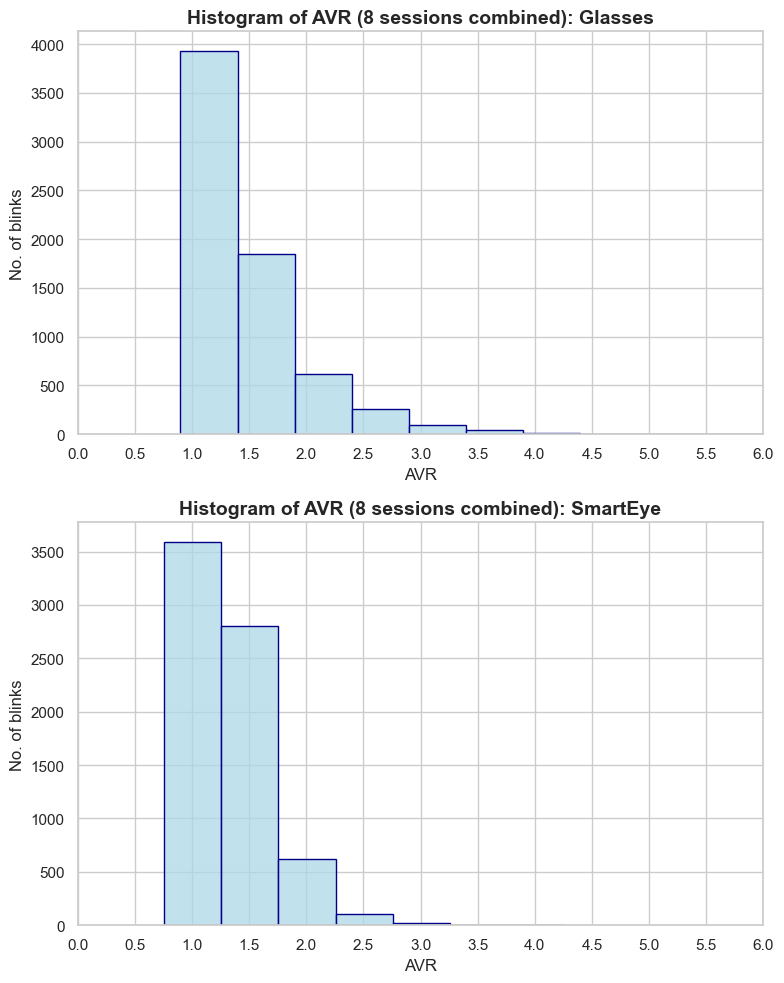

In [56]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(8, 10),
    gridspec_kw={"height_ratios": [5, 5]}
)

# Glasses AVR
sns.histplot(
    data=sm_gl_dt,
    x="avr",
    binwidth=0.5,
    color="lightblue",
    edgecolor="darkblue",
    ax=axes[0]
)
axes[0].set_xlim(0,6)
axes[0].set_xticks(np.arange(0,6.5,0.5))
axes[0].set_xlabel("AVR")
axes[0].set_ylabel("No. of blinks")
axes[0].set_title("Histogram of AVR (8 sessions combined): Glasses", fontsize=14, fontweight="bold")

# SmartEye AVR
sns.histplot(
    data=sm_sm_dt,
    x="avr",
    binwidth=0.5,
    color="lightblue",
    edgecolor="darkblue",
    ax=axes[1]
)
axes[1].set_xlim(0,6)
axes[1].set_xticks(np.arange(0,6.5,0.5))
axes[1].set_xlabel("AVR")
axes[1].set_ylabel("No. of blinks")
axes[1].set_title("Histogram of AVR (8 sessions combined): SmartEye", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()


In [57]:
import pandas as pd
from tabulate import tabulate

# count occurrences of each class
state_counts = sm_8ses_mdt["state20min"].value_counts().sort_index()

# convert to a DataFrame and transpose to match R t(table(...))
state_counts_df = pd.DataFrame(state_counts).T

# optional: reset column names
state_counts_df.columns = [str(col) for col in state_counts_df.columns]

# print table with caption (booktabs style)
print("Table: Distribution of classes using JTV_percentage_20min")
print(tabulate(state_counts_df, headers="keys", tablefmt="github", showindex=False))


Table: Distribution of classes using JTV_percentage_20min
|   not_impaired |   impaired |
|----------------|------------|
|             42 |        126 |



# jdsa full model
################# fit a  model with state20min #################


- Do not understand why only 8 sessions were chosen
- There's no testing, prone to overfitting
- Code uses Linear Regression and different method to avoid kernel crash compared to what is present in R

In [58]:
# indep_var is a list of predictor variable names
state20min_imf = f"state20min_code ~ {' + '.join(indep_var)}"
state20min_imf

'state20min_code ~ LnMeanPositiveZCI + LnStdDevPositiveZCI + LnMeanNegativeZCI + LnStdDevNegativeZCI + LnMeanNegativeIED + LnStdDevNegativeIED + LnMeanBECD + LnStdDevBECD + LnMeanBTD + LnStdDevBTD + LnMeanPositiveAVR + LnStdDevPositiveAVR + LnMeanNegativeAVR + LnStdDevNegativeAVR + LnMeanAVRProduct + LnStdDevAVRProduct'

In [59]:
import pandas as pd
import statsmodels.formula.api as smf

# -----------------------------
# Ensure predictors are numeric and drop rows with NA
# -----------------------------
sm_8ses_mdt[indep_var] = sm_8ses_mdt[indep_var].apply(pd.to_numeric, errors='coerce')
sm_8ses_mdt = sm_8ses_mdt.dropna(subset=indep_var + ['state20min_code'])

# -----------------------------
# Step 1-3: Dynamic formula & dep var
# -----------------------------
state20min_imf = f"state20min_code ~ {' + '.join(indep_var)}"
state20min_dep_var = state20min_imf.split("~")[0].strip()

# -----------------------------
# Step 4: Fit full model and drop offending predictors
# -----------------------------
state20min_full_mod = smf.ols(formula=state20min_imf, data=sm_8ses_mdt).fit()

if state20min_full_mod.params.isna().any():
    valid_vars = state20min_full_mod.params[~state20min_full_mod.params.isna()].index.drop("Intercept")
    state20min_imf_new = f"{state20min_dep_var} ~ {' + '.join(valid_vars)}"
    state20min_full_mod_new = smf.ols(formula=state20min_imf_new, data=sm_8ses_mdt).fit()
else:
    state20min_imf_new = state20min_imf
    state20min_full_mod_new = state20min_full_mod

# -----------------------------
# Step 5: Backward elimination based on p-values
# -----------------------------
def backward_elimination(model, sls=0.05, max_iter=50):
    variables = model.model.exog_names.copy()
    variables.remove("Intercept")
    iteration = 0
    while True:
        iteration += 1
        if iteration > max_iter:
            break
        pvals = model.pvalues[variables]
        max_pval = pvals.max()
        if max_pval > sls:
            worst_var = pvals.idxmax()
            variables.remove(worst_var)
            formula = f"{state20min_dep_var} ~ {' + '.join(variables)}"
            model = smf.ols(formula=formula, data=sm_8ses_mdt).fit()
        else:
            break
    return variables, model

state20min_vars_kept, state20min_final_mod = backward_elimination(state20min_full_mod_new, sls=0.05)

# -----------------------------
# Step 6-7: Final model
# -----------------------------
state20min_imf_final = f"{state20min_dep_var} ~ {' + '.join(state20min_vars_kept)}"
state20min_final_mod = smf.ols(formula=state20min_imf_final, data=sm_8ses_mdt).fit()


In [60]:
len(sm_8ses_mdt)

159

In [61]:
# Calculate JDS values using the final model
sm_8ses_mdt["state20min_8ses_jds"] = state20min_final_mod.predict(sm_8ses_mdt)

# Truncate to range 0–10
sm_8ses_mdt["state20min_8ses_jds"] = sm_8ses_mdt["state20min_jds"].clip(lower=0, upper=10)

# Optional: save to CSV
# sm_mdt.to_csv("smarteye_new_jds_model_2.csv", index=False)


In [62]:
state20min_final_mod.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        state20min_code   R-squared:                       0.482
Model:                            OLS   Adj. R-squared:                  0.469
Method:                 Least Squares   F-statistic:                     35.87
Date:                Wed, 11 Feb 2026   Prob (F-statistic):           3.67e-21
Time:                        14:07:35   Log-Likelihood:                -448.35
No. Observations:                 159   AIC:                             906.7
Df Residuals:                     154   BIC:                             922.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             -77.0205     20.585     -3.742      0.000    -117.685     -36.356
LnStdDevPositiveZCI    -3.2172      1.230     -2.615      0.010      -5.647      -0.787
LnMeanNegativeZCI      18.1560      4.466      4.065      0.000       9.333      26.979
LnMeanBECD              3.8456      0.541      7.113      0.000       2.778       4.914
LnMeanNegativeAVR     -20.7974      5.906     -3.521      0.001     -32.465      -9.129
==============================================================================
Omnibus:                        0.375   Durbin-Watson:                   0.433
Prob(Omnibus):                  0.829   Jarque-Bera (JB):                0.292
Skew:                           0.105   Prob(JB):                        0.864
Kurtosis:                       2.992   Cond. No.                         440.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a lengt

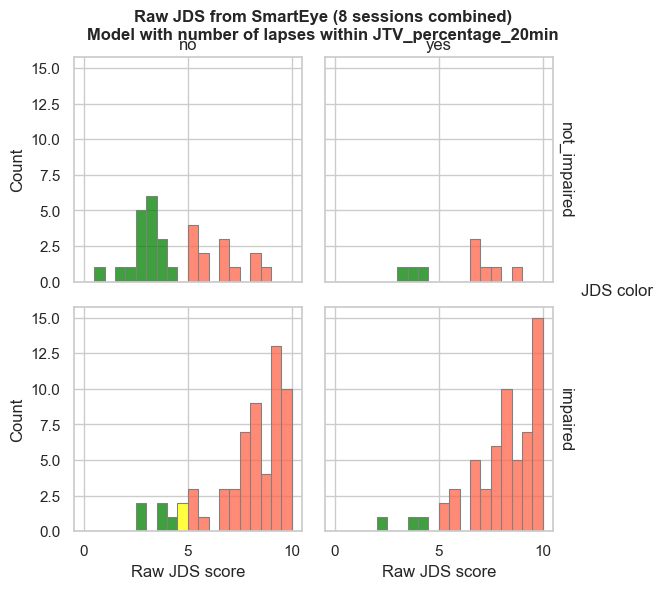

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Prepare data
# -----------------------------
plot_dt = sm_8ses_mdt[['session','state20min','lapsing_minute','state20min_8ses_jds']].copy()
plot_dt = plot_dt.rename(columns={'state20min_8ses_jds':'statelapse_jds'})

# Define color bins
def jds_color(x):
    if x > 5:
        return 'tomato'
    elif x < 4.5:
        return 'green'
    else:
        return 'yellow'

plot_dt['fcolor'] = plot_dt['statelapse_jds'].apply(jds_color)
plot_dt['fcolor'] = pd.Categorical(plot_dt['fcolor'], categories=['green','yellow','tomato'], ordered=True)

# -----------------------------
# Plot
# -----------------------------
g = sns.FacetGrid(plot_dt, row='state20min', col='lapsing_minute', margin_titles=True, despine=False)
g.map_dataframe(
    sns.histplot, 
    x='statelapse_jds', 
    bins=np.arange(0, 10.5, 0.5), 
    hue='fcolor', 
    palette={'green':'green','yellow':'yellow','tomato':'tomato'},
    multiple='stack',
    edgecolor='grey'
)

# Adjust titles and layout
g.set_axis_labels("Raw JDS score", "Count")
g.set_titles(row_template="{row_name}", col_template="{col_name}")
g.add_legend(title='JDS color')
plt.subplots_adjust(top=0.9)
g.fig.suptitle(f"Raw JDS from {model_device} (8 sessions combined)\nModel with number of lapses within JTV_percentage_20min", fontsize=12, fontweight='bold')

plt.show()


C:\Users\VJain\AppData\Local\Temp\ipykernel_10608\2285246934.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sm_8ses_mdt.groupby('statelapsejds_bin_name')


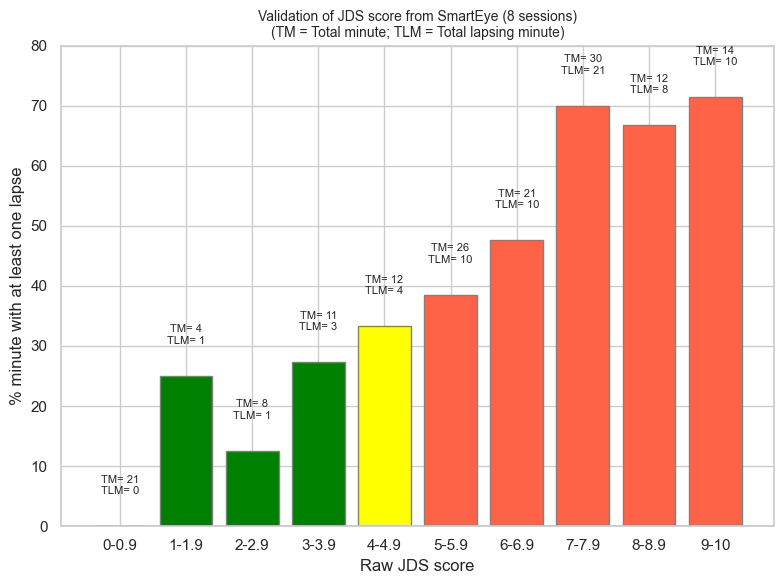

In [64]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -----------------------------
# Bin predicted JDS
# -----------------------------
bin_up = np.array([0.9,1.9,2.9,3.9,4.9,5.9,6.9,7.9,8.9,10])
sm_8ses_mdt['statelapsejds_bin'] = pd.cut(
    sm_8ses_mdt['statelapse_jds'].round(1),
    bins=np.concatenate(([0], bin_up)),
    right=True,
    include_lowest=True
)

sm_8ses_mdt['statelapsejds_bin_name'] = sm_8ses_mdt['statelapsejds_bin'].cat.rename_categories([str(i) for i in range(1,11)])

# -----------------------------
# Calculate % minutes with at least one lapse
# -----------------------------
rr_jds = (
    sm_8ses_mdt.groupby('statelapsejds_bin_name')
    .agg(total_minute=('n_lapses', 'count'),
         n_lapsing_minute=('n_lapses', lambda x: (x>0).sum()))
    .reset_index()
)
rr_jds['lapsing_minute_perc'] = (100 * rr_jds['n_lapsing_minute'] / rr_jds['total_minute']).round(1)

# -----------------------------
# Bar plot
# -----------------------------
bardt = rr_jds
colors = ["green"]*4 + ["yellow"] + ["tomato"]*5
x_pos = np.arange(len(bardt))

fig, ax = plt.subplots(figsize=(8,6))
bars = ax.bar(x_pos, bardt['lapsing_minute_perc'], color=colors, edgecolor='grey')

# Annotate TM and TLM on top of bars
for i, row in bardt.iterrows():
    ax.text(
        i, 
        row['lapsing_minute_perc'] + 5, 
        f"TM= {row['total_minute']}\nTLM= {row['n_lapsing_minute']}",
        ha='center', va='bottom', fontsize=8
    )

# Labels and title
ax.set_xticks(x_pos)
ax.set_xticklabels(["0-0.9","1-1.9","2-2.9","3-3.9","4-4.9","5-5.9","6-6.9","7-7.9","8-8.9","9-10"])
ax.set_ylim(0,80)
ax.set_xlabel("Raw JDS score")
ax.set_ylabel("% minute with at least one lapse")
ax.set_title(f"Validation of JDS score from {model_device} (8 sessions)\n(TM = Total minute; TLM = Total lapsing minute)", fontsize=10)

# x-axis line at 0
ax.axhline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()


C:\Users\VJain\AppData\Local\Temp\ipykernel_10608\319250832.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sm_8ses_mdt.groupby('statelapsejds_bin_name')


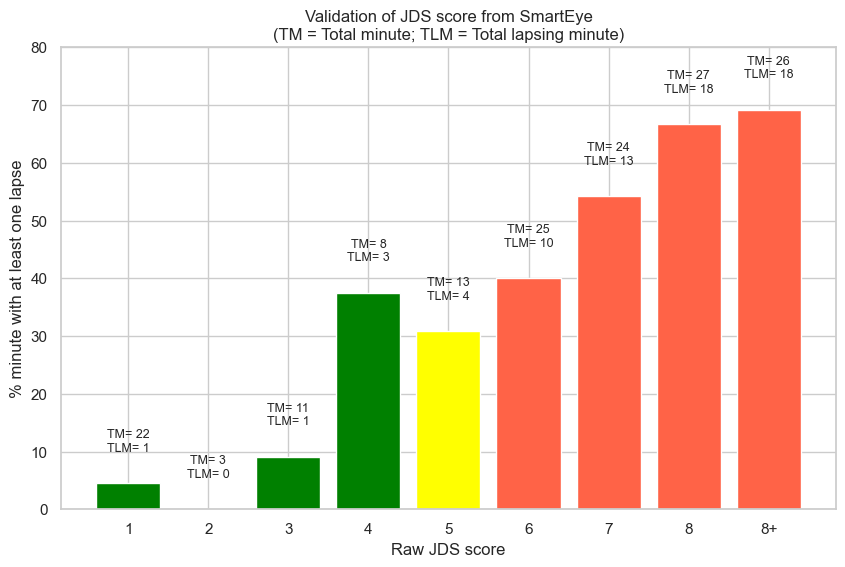

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assuming you already have sm_8ses_mdt with columns:
# "statelapsejds_bin_name", "statelapse_jds", "n_lapses"

# -------------------- Bin raw JDS scores --------------------
bin_edges = [0, 1,2,3,4,5,6,7,8,9,10]  # bins 0-1,1-2,...,9-10
sm_8ses_mdt['statelapsejds_bin'] = pd.cut(
    sm_8ses_mdt['statelapse_jds'].round(1),
    bins=bin_edges,
    right=True,
    include_lowest=True
)

# Create bin labels as strings
bin_labels = ['1','2','3','4','5','6','7','8','9','10']
sm_8ses_mdt['statelapsejds_bin_name'] = sm_8ses_mdt['statelapsejds_bin'].cat.rename_categories(bin_labels)

# -------------------- Calculate lapsing % --------------------
rr_jds = (
    sm_8ses_mdt.groupby('statelapsejds_bin_name')
    .agg(total_minute=('n_lapses','count'),
         n_lapsing_minute=('n_lapses', lambda x: (x>0).sum()))
    .reset_index()
)

rr_jds['lapsing_minute_perc'] = (100 * rr_jds['n_lapsing_minute'] / rr_jds['total_minute']).round(1)

# -------------------- Combine last two bins into "8+" --------------------
rr_jds_8plus = rr_jds[rr_jds['statelapsejds_bin_name'].isin(['9','10'])].sum(numeric_only=True)
rr_jds_8plus['statelapsejds_bin_name'] = '8+'
rr_jds_8plus['lapsing_minute_perc'] = round(100*rr_jds_8plus['n_lapsing_minute']/rr_jds_8plus['total_minute'],1)

# Keep bins 1-8 and append 8+
rr_jds_comb = pd.concat([
    rr_jds[rr_jds['statelapsejds_bin_name'].isin([str(i) for i in range(1,9)])],
    pd.DataFrame([rr_jds_8plus])
], ignore_index=True)

# -------------------- Colors --------------------
def get_color(bin_name):
    if bin_name in ['1','2','3','4']:
        return 'green'
    elif bin_name == '5':
        return 'yellow'
    else:
        return 'tomato'

rr_jds_comb['color'] = rr_jds_comb['statelapsejds_bin_name'].apply(get_color)

# -------------------- Plot --------------------
fig, ax = plt.subplots(figsize=(10,6))

bars = ax.bar(
    rr_jds_comb['statelapsejds_bin_name'],
    rr_jds_comb['lapsing_minute_perc'],
    color=rr_jds_comb['color']
)

# Add labels on top of bars
for bar, tm, tlm in zip(bars, rr_jds_comb['total_minute'], rr_jds_comb['n_lapsing_minute']):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 5,
        f"TM= {int(tm)}\nTLM= {int(tlm)}",
        ha='center',
        va='bottom',
        fontsize=9
    )

# Labels and title
ax.set_xlabel("Raw JDS score")
ax.set_ylabel("% minute with at least one lapse")
ax.set_title(f"Validation of JDS score from {model_device}\n(TM = Total minute; TLM = Total lapsing minute)", fontsize=12)
ax.set_ylim(0,80)

plt.show()


In [66]:
# Assuming sm_8ses_mdt has columns: "session" and "window"
sm_8ses_perminute_obs_subject = (
    sm_8ses_mdt.groupby('session')
    .agg(usable_observations=('window', 'count'))
    .reset_index()
)

sm_8ses_perminute_obs_subject


,session,usable_observations
0,20160817_020230_tm,19
1,20160819_0230_hz,20
2,20160819_0300_tm,20
3,20160819_0326_hz,20
4,20160824_0200_sm,20
5,20160824_0230_hz,20
6,20160824_0300_sm,20
7,20160824_0330_hz,20


# Conclusion


The SmartEye image processing on SmartEye recorded video provide better video modelling. The model with JTV\_percentage\_20min and number of lapses better results compared to the model based on JTV\_percentage\_20min only. 



<br><br><br><br><br><br><br><br><br><br>

# Further work by Vipul

sessions used : sm_8ses_in = [
    "20160817_020230_tm", "20160819_0230_hz",
    "20160819_0300_tm", "20160819_0326_hz",
    "20160824_0200_sm", "20160824_0230_hz",
    "20160824_0300_sm", "20160824_0330_hz"
]<br>
Features selected above: ['LnStdDevPositiveZCI', 'LnMeanNegativeZCI', 'LnMeanBECD', 'LnMeanNegativeAVR'] <br>
Model coeff:
- Intercept -77.02051707013413
- LnStdDevPositiveZCI    -3.217160
- LnMeanNegativeZCI      18.155976
- LnMeanBECD              3.845575
- LnMeanNegativeAVR     -20.797356

In [67]:
########################### final sessions to build model #############################
# Drop sessions according to Murray's suggestions
sm_session_drop = ["20160811_1130_pn", "20160812_0340_pn", "20160812_0440_pn", "20160817_041043_ms"]

# Filter sm_session_final (equivalent to sm_session_in[! basename(sm_session_in) %in% sm_session_drop])
sm_session_final = [path for path in sm_session_in if os.path.basename(path) not in sm_session_drop]

In [68]:
import os
import glob
import pandas as pd

# ---------------- Store summary stats from SmartEye ----------------
sm_ss = []

# ---------------- Read summary stat files ----------------
for s in range(len(sm_session_final)):

    session_path = sm_session_final[s]
    session_name = os.path.basename(session_path)

    # ---- SmartEye summary stats ----
    sm_files = glob.glob(
        os.path.join(session_path, "smarteye", "*summary_stats.csv")
    )

    if sm_files:
        ss = pd.read_csv(sm_files[0])
        ss["device"] = "SmartEye"
        ss["session"] = session_name
        sm_ss.append(ss)

In [69]:
# ---------------- combine data for all sessions ----------------
# Equivalent of do.call(rbind, sm_ss)
sm_mdt = pd.concat(sm_ss, ignore_index=True)

# ---------------- add JTV responses ----------------
sm_mdt = sm_mdt.merge(
    sm_jtv_all[["session", "JTV_percentage_20min"]],
    on="session",
    how="right"
)

# ---------------- add n_lapses responses ----------------
sm_mdt = sm_mdt.merge(
    sm_jtv_pm_lapsing_all[["session", "window", "n_stimuli", "n_lapses"]],
    on=["session", "window"],
    how="right"
)

# ---------------- add state20min (impaired if JTV > 5%) ----------------
sm_mdt["state20min"] = np.where(
    sm_mdt["JTV_percentage_20min"] > 5,
    "impaired",
    "not_impaired"
)

sm_mdt["state20min"] = pd.Categorical(
    sm_mdt["state20min"],
    categories=["not_impaired", "impaired"],
    ordered=True
)

# ---------------- add lapsing_minute (n_lapses > 0) ----------------
sm_mdt["lapsing_minute"] = np.where(
    sm_mdt["n_lapses"] > 0,
    "yes",
    "no"
)

sm_mdt["lapsing_minute"] = pd.Categorical(
    sm_mdt["lapsing_minute"],
    categories=["no", "yes"],
    ordered=True
)

# ---------------- remove NA ----------------
sm_mdt = sm_mdt.dropna()


In [70]:
features_selected = ['LnStdDevPositiveZCI', 'LnMeanNegativeZCI', 'LnMeanBECD', 'LnMeanNegativeAVR']
target_var = 'state20min_code'

In [71]:
features_selected = ['LnMeanPositiveZCI','LnMeanNegativeAVR','LnStdDevNegativeAVR','LnStdDevAVRProduct','LnMeanBTD']

In [72]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# data = sm_8ses_mdt.copy() # this works fine



data = sm_mdt[sm_mdt["session"].isin([
    "20160817_020230_tm", "20160819_0230_hz",
    "20160819_0300_tm", "20160819_0326_hz",
    "20160824_0200_sm", "20160824_0230_hz",
    "20160824_0300_sm", "20160824_0330_hz"
])].copy()
data.columns = data.columns.str.strip()  # remove leading/trailing spaces from column names
data[target_var] = -4
data.loc[sm_mdt["state20min"] == "impaired", target_var] = 9
data[features_selected] = data[features_selected].apply(pd.to_numeric, errors='coerce')
data = data.dropna(subset=features_selected)




X = data[features_selected].copy()
y = data[target_var]

model = LinearRegression(fit_intercept=True).fit(X, y)
coefficients = pd.Series(model.coef_, index=X.columns)
print("Intercept:", model.intercept_)
print(coefficients)
data.loc[:,'pred'] = model.predict(X)
data.loc[:,'pred'] = data['pred'].clip(lower=0, upper=10)

threhold = 4.5
data.loc[:,'pred_color'] = np.where(
    data['pred'] > threhold, 'tomato',  'green')

Intercept: -97.70559599651195
LnMeanPositiveZCI      -0.563784
LnMeanNegativeAVR      -9.740477
LnStdDevNegativeAVR     1.770137
LnStdDevAVRProduct     -4.366269
LnMeanBTD              19.524426
dtype: float64


C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in 

Text(0.5, 1.0, 'Predicted JDS vs Actual state20min_code')

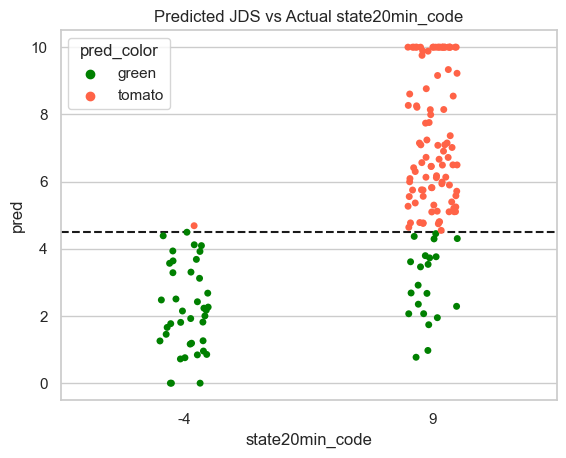

In [73]:
sns.stripplot(data = data, x='state20min_code', y='pred', hue = 'pred_color', palette={'green':'green','tomato':'tomato'})
plt.axhline(threhold, color='k', linestyle='--')
plt.title('Predicted JDS vs Actual state20min_code')

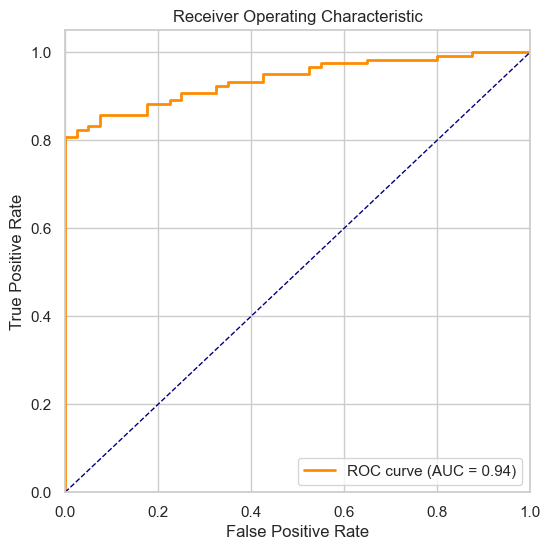

In [74]:
from sklearn.metrics import roc_curve, auc
y_bin = (y > 4.5).astype(int)  # 1 if state > 4.5, else 0
y_score = model.predict(X)  # can keep continuous
fpr, tpr, thresholds = roc_curve(y_bin, y_score)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


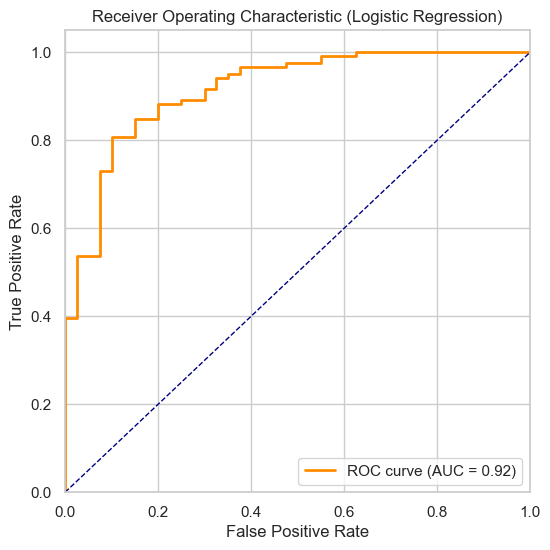

In [75]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X, y_bin)
y_score = clf.predict_proba(X)[:,1]  # probabilities for class 1
fpr, tpr, thresholds = roc_curve(y_bin, y_score)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (Logistic Regression)')
plt.legend(loc="lower right")
plt.show()